In [1]:
#!/usr/bin/env python3

from pathlib import Path
import re

import h5py
import numpy as np
import pandas as pd
from PIL import Image
from scipy.io import loadmat

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms


# ============================================================
# USER SETTINGS
# ============================================================
REPO_DIR = Path("~/Downloads/abstractRepresentationsInMTL-master").expanduser()
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

BATCH_SIZE = 32
N_EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-5
RANDOM_STATE = 42
EXPECTED_N_CATEGORIES = 10

OUT_MODEL = REPO_DIR / "alexnet_10way_final_layer_only.pt"
OUT_TRIAL_LABELS_CSV = REPO_DIR / "alexnet_10way_trial_labels.csv"
OUT_STIMULUS_SPACE_CSV = REPO_DIR / "alexnet_10way_tsne_stimulus_space_2d.csv"
OUT_TRIAL_SPACE_CSV = REPO_DIR / "alexnet_10way_tsne_trial_space_2d.csv"
OUT_TRAINING_HISTORY_CSV = REPO_DIR / "alexnet_10way_training_history.csv"
OUT_NEURAL_TRIALS_NPY = REPO_DIR / "zvals_trials_units_by_trials.npy"


# ============================================================
# MATLAB / HDF5 HELPERS
# ============================================================
def safe_str(x):
    if isinstance(x, str):
        return x
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="ignore")
    if isinstance(x, np.bytes_):
        return x.decode("utf-8", errors="ignore")
    if isinstance(x, np.str_):
        return str(x)
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return ""
        if x.ndim == 0:
            return safe_str(x.item())
        if x.dtype.kind in {"u", "i"}:
            vals = x.reshape(-1).tolist()
            return "".join(chr(int(v)) for v in vals if int(v) != 0)
        if x.dtype.kind in {"U", "S"}:
            return "".join(x.astype(str).reshape(-1)).strip()
        return safe_str(x.reshape(-1)[0])
    return str(x)


def matlab_cellstr_to_list(arr):
    return [safe_str(x) for x in np.asarray(arr).reshape(-1)]


def is_mat_v73(file_path):
    try:
        with h5py.File(file_path, "r"):
            return True
    except Exception:
        return False


def read_h5_string_like(x):
    arr = np.array(x)
    return safe_str(arr.item()) if arr.ndim == 0 else safe_str(arr)


def read_h5_cellstr(f, key):
    raw = np.array(f[key])
    out = []
    for item in raw.reshape(-1):
        if isinstance(item, h5py.Reference):
            out.append(read_h5_string_like(f[item]) if item else "")
        else:
            out.append(read_h5_string_like(item))
    return out


def read_numeric_array_any(file_path, key):
    file_path = Path(file_path).expanduser()
    if is_mat_v73(file_path):
        with h5py.File(file_path, "r") as f:
            return np.array(f[key])
    mat = loadmat(file_path, squeeze_me=True, struct_as_record=False)
    return np.asarray(mat[key])


def read_lookup_any(file_path, key):
    file_path = Path(file_path).expanduser()
    if is_mat_v73(file_path):
        with h5py.File(file_path, "r") as f:
            return read_h5_cellstr(f, key)
    mat = loadmat(file_path, squeeze_me=True, struct_as_record=False)
    return matlab_cellstr_to_list(mat[key])


def maybe_transpose_units_by_trials(arr, target_units=None, target_trials=None):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D neural matrix, received {arr.shape}.")
    if target_units is not None:
        if arr.shape[0] == target_units:
            return arr
        if arr.shape[1] == target_units:
            return arr.T
    if target_trials is not None:
        if arr.shape[1] == target_trials:
            return arr
        if arr.shape[0] == target_trials:
            return arr.T
    return arr


def load_zvals_mean(repo_dir):
    fp = repo_dir / "zvals.mat"
    zvals = np.asarray(read_numeric_array_any(fp, "zvals"), dtype=float)
    stim_lookup = read_lookup_any(fp, "stim_lookup")
    if len(stim_lookup) == zvals.shape[0] and len(stim_lookup) != zvals.shape[1]:
        zvals = zvals.T
    return zvals, stim_lookup


def load_zvals_trials(repo_dir, n_units_expected):
    h5_fp = repo_dir / "zvals_trials.h5"
    mat_fp = repo_dir / "zvals_trials.mat"
    if h5_fp.exists():
        fp = h5_fp
    elif mat_fp.exists():
        fp = mat_fp
    else:
        raise FileNotFoundError("Could not find zvals_trials.h5 or zvals_trials.mat")

    zvals = read_numeric_array_any(fp, "zvals")
    stim_lookup = read_lookup_any(fp, "stim_lookup")
    cat_lookup = read_lookup_any(fp, "cat_lookup")
    zvals = maybe_transpose_units_by_trials(
        zvals,
        target_units=n_units_expected,
        target_trials=len(stim_lookup)
    )
    return zvals, stim_lookup, cat_lookup


# ============================================================
# LABEL HELPERS
# ============================================================
def clean_response_string(resp):
    s = str(resp).strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s)
    return s.strip("_")


NATURAL_CATEGORIES = {"wild_animals", "fruit", "flowers", "insects", "birds"}
MANMADE_CATEGORIES = {"manmade_food", "clothes", "furniture", "instruments", "computer"}


def category_to_binary(category):
    category = clean_response_string(category)
    if category in NATURAL_CATEGORIES:
        return "natural"
    if category in MANMADE_CATEGORIES:
        return "manmade"
    return np.nan


# ============================================================
# IMAGE MATCHING
# ============================================================
def normalize_name(x):
    return Path(str(x)).stem.lower().replace(" ", "").replace("_", "").replace("-", "")


def build_image_index(repo_dir):
    image_files = []
    for ext in IMAGE_EXTS:
        image_files.extend(repo_dir.rglob(f"*{ext}"))
        image_files.extend(repo_dir.rglob(f"*{ext.upper()}"))

    index = {}
    for fp in image_files:
        key = normalize_name(fp.stem)
        if key not in index:
            index[key] = fp
    return index


def find_image_for_stim(stim_name, image_index):
    key = normalize_name(stim_name)
    if key in image_index:
        return image_index[key]
    matches = [fp for indexed_key, fp in image_index.items() if key in indexed_key or indexed_key in key]
    return matches[0] if matches else None


# ============================================================
# DATASET
# ============================================================
class StimDataset(Dataset):
    def __init__(self, df, transform, return_trial_index=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.return_trial_index = return_trial_index

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        category_label = int(row["category_label_id"])
        stim_name = str(row["stim_name"])

        if self.return_trial_index:
            return img, category_label, stim_name, int(row["trial_index"])

        return img, category_label, stim_name


# ============================================================
# PRETRAINED ALEXNET: ONLY FINAL 10-WAY LAYER IS TRAINABLE
# ============================================================
class AlexNet10Way(nn.Module):
    def __init__(self, n_categories=10):
        super().__init__()

        self.model = models.alexnet(
            weights=models.AlexNet_Weights.IMAGENET1K_V1
        )

        # Freeze the entire pretrained network.
        for param in self.model.parameters():
            param.requires_grad = False

        # Replace the original 1000-way ImageNet output layer.
        # This new layer is the ONLY trainable layer.
        in_features = self.model.classifier[6].in_features
        self.model.classifier[6] = nn.Linear(in_features, n_categories)

        for param in self.model.classifier[6].parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

    def extract_penultimate_features(self, x):
        """
        Return the 4096-D activation immediately before the trainable
        10-way classifier. These features are used as input to UMAP.
        """
        x = self.model.features(x)
        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)

        # AlexNet classifier:
        # Dropout -> Linear -> ReLU -> Dropout -> Linear -> ReLU -> Linear
        for layer in list(self.model.classifier.children())[:-1]:
            x = layer(x)

        return x


# ============================================================
# HELPERS
# ============================================================
def modal_value(x):
    mode = x.mode(dropna=True)
    return mode.iloc[0] if len(mode) else np.nan


def print_trainable_parameters(model):
    trainable = [
        (name, p.numel())
        for name, p in model.named_parameters()
        if p.requires_grad
    ]
    n_trainable = sum(n for _, n in trainable)
    n_total = sum(p.numel() for p in model.parameters())

    print("\nTrainable parameters:")
    for name, n in trainable:
        print(f"  {name}: {n:,}")

    print(f"Total trainable parameters: {n_trainable:,}")
    print(f"Total model parameters: {n_total:,}")


# ============================================================
# MAIN
# ============================================================
def main():
    from sklearn.manifold import TSNE

    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # --------------------------------------------------------
    # Load behavioral/neural trial metadata
    # --------------------------------------------------------
    zvals_mean, _ = load_zvals_mean(REPO_DIR)
    zvals_trials, stim_lookup_trials, cat_lookup_trials = load_zvals_trials(
        REPO_DIR,
        n_units_expected=zvals_mean.shape[0]
    )

    if len(stim_lookup_trials) != len(cat_lookup_trials):
        raise RuntimeError("stim_lookup and cat_lookup have different lengths")

    if zvals_trials.shape[1] != len(stim_lookup_trials):
        raise RuntimeError(
            f"Neural trials do not align with stimulus trials: "
            f"{zvals_trials.shape} versus {len(stim_lookup_trials)}"
        )

    trial_df = pd.DataFrame({
        "trial_index": np.arange(len(stim_lookup_trials)),
        "stim_name": stim_lookup_trials,
        "behavioral_response_raw": cat_lookup_trials
    })

    trial_df["behavioral_response_category"] = (
        trial_df["behavioral_response_raw"]
        .astype(str)
        .map(clean_response_string)
    )

    print("\nRaw behavioral response counts:")
    print(trial_df["behavioral_response_raw"].value_counts(dropna=False))

    print("\nSpecific category counts:")
    print(
        trial_df["behavioral_response_category"]
        .value_counts(dropna=False)
    )

    # --------------------------------------------------------
    # Match trials to image files
    # --------------------------------------------------------
    image_index = build_image_index(REPO_DIR)
    print("\nFound image files:", len(image_index))

    trial_df["image_path"] = trial_df["stim_name"].apply(
        lambda s: find_image_for_stim(s, image_index)
    )

    print(
        "Trials without specific category:",
        trial_df["behavioral_response_category"].isna().sum()
    )
    print(
        "Trials without matched image:",
        trial_df["image_path"].isna().sum()
    )

    train_df = trial_df.dropna(
        subset=[
            "image_path",
            "behavioral_response_category"
        ]
    ).copy()

    train_df["image_path"] = train_df["image_path"].astype(str)

    category_class_names = sorted(
        train_df["behavioral_response_category"]
        .unique()
        .tolist()
    )

    print("\nDetected category classes:")
    for idx, name in enumerate(category_class_names):
        print(f"  {idx}: {name}")

    if len(category_class_names) != EXPECTED_N_CATEGORIES:
        raise RuntimeError(
            f"Expected {EXPECTED_N_CATEGORIES} categories, found "
            f"{len(category_class_names)}: {category_class_names}"
        )

    category_to_id = {
        name: idx
        for idx, name in enumerate(category_class_names)
    }

    category_id_to_class = {
        idx: name
        for name, idx in category_to_id.items()
    }

    train_df["category_label_id"] = (
        train_df["behavioral_response_category"]
        .map(category_to_id)
        .astype(int)
    )

    train_df.to_csv(OUT_TRIAL_LABELS_CSV, index=False)

    print("\nN training trials:", len(train_df))
    print("N unique stimuli:", train_df["stim_name"].nunique())
    print("Saved trial labels:", OUT_TRIAL_LABELS_CSV)

    # --------------------------------------------------------
    # AlexNet preprocessing
    # --------------------------------------------------------
    transform_train = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    train_ds = StimDataset(
        train_df,
        transform_train,
        return_trial_index=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    # --------------------------------------------------------
    # Model: pretrained AlexNet, only classifier[6] adjustable
    # --------------------------------------------------------
    model = AlexNet10Way(
        n_categories=EXPECTED_N_CATEGORIES
    ).to(device)

    print_trainable_parameters(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    training_history = []

    # --------------------------------------------------------
    # Train only the new 10-way classifier layer
    # --------------------------------------------------------
    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        # Keep the frozen pretrained feature extractor deterministic.
        model.model.features.eval()
        model.model.avgpool.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        for imgs, category_labels, _, _ in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            category_labels = category_labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            logits = model(imgs)
            loss = criterion(logits, category_labels)

            loss.backward()
            optimizer.step()

            current_batch_size = imgs.size(0)
            running_loss += loss.item() * current_batch_size
            correct += (
                logits.argmax(dim=1) == category_labels
            ).sum().item()
            total += current_batch_size

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total
        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "category_loss": epoch_loss,
            "category_accuracy": epoch_accuracy,
            "learning_rate": current_lr
        }

        training_history.append(row)
        scheduler.step(epoch_loss)

        print(
            f"Epoch {epoch:03d} | "
            f"loss={epoch_loss:.4f} | "
            f"accuracy={epoch_accuracy:.3f} | "
            f"lr={current_lr:.2e}"
        )

    pd.DataFrame(training_history).to_csv(
        OUT_TRAINING_HISTORY_CSV,
        index=False
    )

    torch.save({
        "model_state_dict": model.state_dict(),
        "category_class_names": category_class_names,
        "category_to_id": category_to_id,
        "category_id_to_class": category_id_to_class,
        "n_categories": EXPECTED_N_CATEGORIES,
        "n_epochs": N_EPOCHS,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "random_state": RANDOM_STATE,
        "backbone": "torchvision pretrained AlexNet ImageNet",
        "trainable_layer": "model.classifier.6",
        "tsne_input": "4096-D AlexNet penultimate-layer activations"
    }, OUT_MODEL)

    print("\nSaved model:", OUT_MODEL)

    # --------------------------------------------------------
    # Build one deterministic 4096-D representation per stimulus
    # --------------------------------------------------------
    stim_df = (
        train_df
        .groupby("stim_name", as_index=False)
        .agg(
            image_path=("image_path", "first"),
            behavioral_response_category=(
                "behavioral_response_category",
                modal_value
            ),
            n_behavioral_trials=("trial_index", "count")
        )
    )

    stim_df["category_label_id"] = (
        stim_df["behavioral_response_category"]
        .map(category_to_id)
        .astype(int)
    )

    eval_ds = StimDataset(
        stim_df,
        transform_eval,
        return_trial_index=False
    )

    eval_loader = DataLoader(
        eval_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    model.eval()

    all_stims = []
    all_features = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for imgs, _, stim_names in eval_loader:
            imgs = imgs.to(device, non_blocking=True)

            penultimate_features = (
                model.extract_penultimate_features(imgs)
            )
            logits = model.model.classifier[6](
                penultimate_features
            )
            probabilities = torch.softmax(logits, dim=1)

            all_stims.extend(list(stim_names))
            all_features.append(
                penultimate_features.cpu().numpy()
            )
            all_predictions.extend(
                probabilities.argmax(dim=1)
                .cpu()
                .numpy()
                .tolist()
            )
            all_confidences.extend(
                probabilities.max(dim=1)
                .values
                .cpu()
                .numpy()
                .tolist()
            )

    feature_array = np.vstack(all_features)

    if feature_array.shape[1] != 4096:
        raise RuntimeError(
            f"Expected 4096-D penultimate features, received "
            f"{feature_array.shape}"
        )

    # --------------------------------------------------------
    # Fit t-SNE and create the requested 2D bottleneck
    # --------------------------------------------------------
    n_stimuli = feature_array.shape[0]
    perplexity = min(30.0, max(5.0, (n_stimuli - 1) / 3.0))

    tsne_model = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=2000,
        metric="cosine",
        random_state=RANDOM_STATE
    )

    bottleneck_array = tsne_model.fit_transform(feature_array)

    if bottleneck_array.shape[1] != 2:
        raise RuntimeError(
            f"Expected a 2D t-SNE embedding, received "
            f"{bottleneck_array.shape}"
        )

    stimulus_space_df = pd.DataFrame({
        "stim_name": all_stims,
        "bottleneck_1": bottleneck_array[:, 0],
        "bottleneck_2": bottleneck_array[:, 1],
        "predicted_category_id": all_predictions,
        "predicted_category": [
            category_id_to_class[int(x)]
            for x in all_predictions
        ],
        "predicted_category_confidence": all_confidences
    })

    stimulus_space_df = stimulus_space_df.merge(
        stim_df[[
            "stim_name",
            "behavioral_response_category",
            "category_label_id",
            "image_path",
            "n_behavioral_trials"
        ]],
        on="stim_name",
        how="left",
        validate="one_to_one"
    )

    stimulus_space_df["category_name"] = (
        stimulus_space_df[
            "behavioral_response_category"
        ]
    )

    stimulus_space_df.to_csv(
        OUT_STIMULUS_SPACE_CSV,
        index=False
    )

    # Assign each trial the fixed UMAP coordinates of its stimulus.
    trial_space_df = train_df.merge(
        stimulus_space_df[[
            "stim_name",
            "bottleneck_1",
            "bottleneck_2",
            "predicted_category_id",
            "predicted_category",
            "predicted_category_confidence"
        ]],
        on="stim_name",
        how="left",
        validate="many_to_one"
    ).sort_values("trial_index")

    trial_space_df.to_csv(
        OUT_TRIAL_SPACE_CSV,
        index=False
    )

    # Save the neural matrix in original units x trials order.
    np.save(
        OUT_NEURAL_TRIALS_NPY,
        zvals_trials
    )

    stimulus_accuracy = np.mean(
        stimulus_space_df[
            "predicted_category_id"
        ].to_numpy(dtype=int)
        ==
        stimulus_space_df[
            "category_label_id"
        ].to_numpy(dtype=int)
    )

    print("\nSaved 2D t-SNE stimulus space:", OUT_STIMULUS_SPACE_CSV)
    print("Saved trial-level 2D t-SNE space:", OUT_TRIAL_SPACE_CSV)
    print("Saved training history:", OUT_TRAINING_HISTORY_CSV)
    print("Saved neural trial matrix:", OUT_NEURAL_TRIALS_NPY)
    print(
        f"Unique-stimulus 10-way category accuracy: "
        f"{stimulus_accuracy:.3f}"
    )
    print("Finished.")


if __name__ == "__main__":
    main()

Device: cpu

Raw behavioral response counts:
behavioral_response_raw
wild_animals    100
fruit           100
flowers         100
insects         100
birds           100
manmade_food    100
clothes         100
furniture       100
instruments     100
computer        100
Name: count, dtype: int64

Specific category counts:
behavioral_response_category
wild_animals    100
fruit           100
flowers         100
insects         100
birds           100
manmade_food    100
clothes         100
furniture       100
instruments     100
computer        100
Name: count, dtype: int64

Found image files: 120
Trials without specific category: 0
Trials without matched image: 0

Detected category classes:
  0: birds
  1: clothes
  2: computer
  3: flowers
  4: fruit
  5: furniture
  6: insects
  7: instruments
  8: manmade_food
  9: wild_animals

N training trials: 1000
N unique stimuli: 100
Saved trial labels: /Users/th3253/Downloads/abstractRepresentationsInMTL-master/alexnet_10way_trial_labels.csv

T

In [2]:
#!/usr/bin/env python3

from pathlib import Path
import os
import numpy as np
import pandas as pd
import h5py
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from skimage.transform import rotate
from joblib import Parallel, delayed, parallel_config


# ============================================================
# USER SETTINGS
# ============================================================
REPO_DIR = Path("~/Downloads/abstractRepresentationsInMTL-master").expanduser()

PCA_CSV = REPO_DIR / "alexnet_10way_tsne_stimulus_space_2d.csv"

OUT_GRID_CSV = REPO_DIR / "alexnet_pca_grid_cells.csv"
OUT_UNIT_MAPS_CSV = REPO_DIR / "alexnet_pca_unit_rate_maps_long.csv"

N_BINS = 30
SMOOTH_SIGMA = 1.5

MIN_TRIALS_PER_UNIT = 20
MIN_OCCUPANCY_PER_BIN = 1
MIN_VISITED_BINS = 10

N_PERM = 1000
GRID_ALPHA = 0.05

RANDOM_STATE = 42
VERBOSE = True

# Parallel settings
# -1 = use all logical CPU cores; on a laptop, -2 leaves one core free.
N_JOBS = -2
JOBLIB_BACKEND = "loky"
JOBLIB_VERBOSE = 10


# ============================================================
# BASIC HELPERS
# ============================================================
def log(msg):
    if VERBOSE:
        print(msg, flush=True)


def safe_str(x):
    if isinstance(x, str):
        return x
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="ignore")
    if isinstance(x, np.bytes_):
        return x.decode("utf-8", errors="ignore")
    if isinstance(x, np.str_):
        return str(x)

    if isinstance(x, np.ndarray):
        if x.size == 0:
            return ""
        if x.ndim == 0:
            return safe_str(x.item())

        if x.dtype.kind in {"u", "i"}:
            vals = x.reshape(-1).tolist()
            return "".join(chr(int(v)) for v in vals if int(v) != 0)

        if x.dtype.kind in {"U", "S"}:
            return "".join(x.astype(str).reshape(-1)).strip()

        if x.size == 1:
            return safe_str(x.reshape(-1)[0])

        return safe_str(x.reshape(-1)[0])

    return str(x)


def matlab_cellstr_to_list(arr):
    arr = np.asarray(arr)
    return [safe_str(x) for x in arr.reshape(-1)]


def is_mat_v73(file_path):
    try:
        with h5py.File(file_path, "r"):
            return True
    except Exception:
        return False


def read_h5_string_like(x):
    arr = np.array(x)
    if arr.ndim == 0:
        return safe_str(arr.item())
    return safe_str(arr)


def read_h5_cellstr(f, key):
    raw = np.array(f[key])
    flat = raw.reshape(-1)
    out = []

    for item in flat:
        if isinstance(item, h5py.Reference):
            if not item:
                out.append("")
            else:
                out.append(read_h5_string_like(f[item]))
        else:
            out.append(read_h5_string_like(item))

    return out


def read_numeric_array_any(file_path, key):
    file_path = Path(file_path).expanduser()

    if is_mat_v73(file_path):
        with h5py.File(file_path, "r") as f:
            return np.array(f[key])
    else:
        m = loadmat(file_path, squeeze_me=True, struct_as_record=False)
        return np.asarray(m[key])


def read_lookup_any(file_path, key):
    file_path = Path(file_path).expanduser()

    if is_mat_v73(file_path):
        with h5py.File(file_path, "r") as f:
            return read_h5_cellstr(f, key)
    else:
        m = loadmat(file_path, squeeze_me=True, struct_as_record=False)
        return matlab_cellstr_to_list(m[key])


def maybe_transpose_units_by_trials(arr, target_units=None, target_trials=None):
    arr = np.asarray(arr, dtype=float)

    if target_units is not None:
        if arr.shape[0] == target_units:
            return arr
        if arr.shape[1] == target_units:
            return arr.T

    if target_trials is not None:
        if arr.shape[1] == target_trials:
            return arr
        if arr.shape[0] == target_trials:
            return arr.T

    return arr


# ============================================================
# LOAD DATA
# ============================================================
def load_zvals_mean(repo_dir):
    fp = repo_dir / "zvals.mat"
    zvals = np.asarray(read_numeric_array_any(fp, "zvals"), dtype=float)
    stim_lookup = read_lookup_any(fp, "stim_lookup")

    if len(stim_lookup) == zvals.shape[0] and len(stim_lookup) != zvals.shape[1]:
        zvals = zvals.T

    return zvals, stim_lookup


def load_zvals_trials(repo_dir, n_units_expected):
    h5_fp = repo_dir / "zvals_trials.h5"
    mat_fp = repo_dir / "zvals_trials.mat"

    if h5_fp.exists():
        fp = h5_fp
    elif mat_fp.exists():
        fp = mat_fp
    else:
        raise FileNotFoundError("Could not find zvals_trials.h5 or zvals_trials.mat")

    zvals = read_numeric_array_any(fp, "zvals")
    stim_lookup = read_lookup_any(fp, "stim_lookup")
    cat_lookup = read_lookup_any(fp, "cat_lookup")

    zvals = maybe_transpose_units_by_trials(
        zvals,
        target_units=n_units_expected,
        target_trials=len(stim_lookup)
    )

    return zvals, stim_lookup, cat_lookup


# ============================================================
# GRID HELPERS
# ============================================================
def make_rate_map(x, y, fr, x_edges, y_edges):
    """Vectorized rate-map construction; much faster than the Python zip loop."""
    n_x = len(x_edges) - 1
    n_y = len(y_edges) - 1

    bx = np.searchsorted(x_edges, x, side="right") - 1
    by = np.searchsorted(y_edges, y, side="right") - 1

    # Include values exactly equal to the upper edge in the last bin.
    bx[bx == n_x] = n_x - 1
    by[by == n_y] = n_y - 1

    keep = (
        np.isfinite(x) & np.isfinite(y) & np.isfinite(fr) &
        (bx >= 0) & (bx < n_x) &
        (by >= 0) & (by < n_y)
    )

    flat_bin = by[keep] * n_x + bx[keep]
    fr_keep = fr[keep]

    occ = np.bincount(flat_bin, minlength=n_x * n_y).reshape(n_y, n_x).astype(float)
    val = np.bincount(flat_bin, weights=fr_keep, minlength=n_x * n_y).reshape(n_y, n_x)

    rate = np.full((n_y, n_x), np.nan, dtype=float)
    valid = occ >= MIN_OCCUPANCY_PER_BIN
    rate[valid] = val[valid] / occ[valid]

    # Smooth safely.
    rate_filled = np.where(np.isfinite(rate), rate, 0.0)
    occ_mask = np.isfinite(rate).astype(float)

    sm_num = gaussian_filter(rate_filled * occ_mask, SMOOTH_SIGMA)
    sm_den = gaussian_filter(occ_mask, SMOOTH_SIGMA)

    sm_rate = np.full_like(rate, np.nan)
    ok = sm_den > 1e-8
    sm_rate[ok] = sm_num[ok] / sm_den[ok]

    return sm_rate, occ


def autocorr2d(rate_map):
    """
    2D spatial autocorrelation via normalized cross-correlation.
    """
    M = np.array(rate_map, dtype=float)
    valid = np.isfinite(M)

    if valid.sum() < 5:
        return None

    mean_val = np.nanmean(M)
    M = np.where(valid, M - mean_val, 0.0)

    F = np.fft.fft2(M, s=(M.shape[0] * 2 - 1, M.shape[1] * 2 - 1))
    ac = np.fft.ifft2(F * np.conj(F)).real
    ac = np.fft.fftshift(ac)

    norm = np.nanmax(np.abs(ac))
    if norm <= 1e-12:
        return None

    return ac / norm


def annulus_mask(shape, inner_frac=0.2, outer_frac=0.75):
    h, w = shape
    yy, xx = np.indices(shape)
    cy = (h - 1) / 2
    cx = (w - 1) / 2
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

    maxr = min(h, w) / 2
    return (rr >= inner_frac * maxr) & (rr <= outer_frac * maxr)


def corr_on_mask(A, B, mask):
    a = A[mask]
    b = B[mask]

    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 10:
        return np.nan

    if np.std(a[ok]) <= 1e-12 or np.std(b[ok]) <= 1e-12:
        return np.nan

    return float(pearsonr(a[ok], b[ok])[0])


def grid_score(rate_map):
    """
    Classic gridness:
    min(corr60, corr120) - max(corr30, corr90, corr150)
    on the spatial autocorrelogram.
    """
    ac = autocorr2d(rate_map)
    if ac is None:
        return np.nan

    mask = annulus_mask(ac.shape)

    corrs = {}
    for angle in [30, 60, 90, 120, 150]:
        rot = rotate(ac, angle=angle, resize=False, preserve_range=True)
        corrs[angle] = corr_on_mask(ac, rot, mask)

    if any(not np.isfinite(corrs[a]) for a in corrs):
        return np.nan

    return float(
        min(corrs[60], corrs[120]) -
        max(corrs[30], corrs[90], corrs[150])
    )


def nearest_neighbor_trial_shuffle(fr, rng):
    return rng.permutation(fr)


# ============================================================
# MAIN
# ============================================================
def process_unit(unit_idx, zvals_trials, x, y, x_edges, y_edges):
    """Analyze one unit. Each worker gets an independent deterministic RNG."""
    rng = np.random.default_rng(np.random.SeedSequence([RANDOM_STATE, unit_idx]))
    fr = np.asarray(zvals_trials[unit_idx, :], dtype=float)

    ok = np.isfinite(fr) & np.isfinite(x) & np.isfinite(y)
    if ok.sum() < MIN_TRIALS_PER_UNIT:
        return None

    xu = x[ok]
    yu = y[ok]
    fru = fr[ok]

    rate_map, occ_map = make_rate_map(xu, yu, fru, x_edges, y_edges)
    visited_bins = int(np.sum(occ_map >= MIN_OCCUPANCY_PER_BIN))
    if visited_bins < MIN_VISITED_BINS:
        return None

    grid_obs = grid_score(rate_map)

    grid_null = np.full(N_PERM, np.nan, dtype=float)

    for p in range(N_PERM):
        fr_perm = rng.permutation(fru)
        rm_perm, occ_perm = make_rate_map(xu, yu, fr_perm, x_edges, y_edges)
        grid_null[p] = grid_score(rm_perm)

    grid_den = np.sum(np.isfinite(grid_null))

    grid_p = (1 + np.sum(grid_null >= grid_obs)) / (1 + grid_den)

    grid_row = {
        "unit_index": unit_idx,
        "n_trials": int(ok.sum()),
        "visited_bins": visited_bins,
        "grid_score": grid_obs,
        "grid_score_p": grid_p,
        "grid_cell": bool(grid_p < GRID_ALPHA)
    }

    yy, xx = np.indices(rate_map.shape)
    map_df = pd.DataFrame({
        "unit_index": unit_idx,
        "pca_bin_y": yy.ravel(),
        "pca_bin_x": xx.ravel(),
        "rate": rate_map.ravel(),
        "occupancy": occ_map.ravel(),
        "x_bin_center": (0.5 * (x_edges[:-1] + x_edges[1:]))[xx.ravel()],
        "y_bin_center": (0.5 * (y_edges[:-1] + y_edges[1:]))[yy.ravel()]
    })

    return grid_row, map_df


def main():
    print("REPO_DIR:", REPO_DIR)

    if not PCA_CSV.exists():
        raise FileNotFoundError(f"Missing PCA CSV: {PCA_CSV}")

    zvals_mean, stim_lookup_mean = load_zvals_mean(REPO_DIR)
    zvals_trials, stim_lookup_trials, cat_lookup_trials = load_zvals_trials(
        REPO_DIR,
        n_units_expected=zvals_mean.shape[0]
    )

    n_units, n_trials = zvals_trials.shape
    pca_df = pd.read_csv(PCA_CSV)

    required_cols = {"stim_name", "bottleneck_1", "bottleneck_2"}
    missing_cols = required_cols - set(pca_df.columns)
    if missing_cols:
        raise ValueError(f"PCA file missing columns: {missing_cols}")

    trial_df = pd.DataFrame({
        "trial_index": np.arange(n_trials),
        "stim_name": stim_lookup_trials,
        "category_name": cat_lookup_trials
    })

    trial_df = trial_df.merge(
        pca_df[["stim_name", "bottleneck_1", "bottleneck_2"]],
        on="stim_name",
        how="left"
    )

    missing_pca = trial_df["bottleneck_1"].isna().sum()
    print("Trials missing PCA coords:", missing_pca)

    trial_df = trial_df.dropna(subset=["bottleneck_1", "bottleneck_2"]).reset_index(drop=True)
    kept_trial_idx = trial_df["trial_index"].to_numpy(dtype=int)
    zvals_trials = np.ascontiguousarray(zvals_trials[:, kept_trial_idx], dtype=float)

    x = trial_df["bottleneck_1"].to_numpy(dtype=float)
    y = trial_df["bottleneck_2"].to_numpy(dtype=float)
    x_edges = np.linspace(np.nanmin(x), np.nanmax(x), N_BINS + 1)
    y_edges = np.linspace(np.nanmin(y), np.nanmax(y), N_BINS + 1)

    print("Testing units:", n_units)
    print("Parallel workers:", os.cpu_count() if N_JOBS == -1 else N_JOBS)

    # Parallelize across units, not permutations. This avoids nested-process overhead.
    # inner_max_num_threads=1 prevents NumPy/SciPy from spawning extra threads inside
    # every worker and oversubscribing the machine.
    with parallel_config(
        backend=JOBLIB_BACKEND,
        n_jobs=N_JOBS,
        inner_max_num_threads=1,
        max_nbytes="10M",
        mmap_mode="r"
    ):
        results = Parallel(verbose=JOBLIB_VERBOSE, batch_size=1)(
            delayed(process_unit)(
                unit_idx, zvals_trials, x, y, x_edges, y_edges
            )
            for unit_idx in range(n_units)
        )

    results = [r for r in results if r is not None]
    grid_df = pd.DataFrame([r[0] for r in results])
    map_df = pd.concat([r[1] for r in results], ignore_index=True) if results else pd.DataFrame()

    grid_df.to_csv(OUT_GRID_CSV, index=False)
    map_df.to_csv(OUT_UNIT_MAPS_CSV, index=False)

    print("\nDONE")
    print("Saved:", OUT_GRID_CSV)
    print("Saved:", OUT_UNIT_MAPS_CSV)

    if not grid_df.empty:
        print("\nGrid-cell count:")
        print(grid_df["grid_cell"].value_counts(dropna=False))


if __name__ == "__main__":
    main()

REPO_DIR: /Users/th3253/Downloads/abstractRepresentationsInMTL-master
Trials missing PCA coords: 0
Testing units: 5033
Parallel workers: -2


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-2)]: Done   4 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-2)]: Done  13 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-2)]: Done  22 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-2)]: Done  33 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-2)]: Done  44 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-2)]: Done  57 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-2)]: Done  70 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-2)]: Done  85 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-2)]: Done 100 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-2)]: Done 117 tasks      | elapsed:   14.4s
[Parallel(n_jobs=-2)]: Done 134 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-2)]: Done 153 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-2)]: Done 172 tasks      | elapsed:   20.4s
[Parallel(n_jobs=-2)]: Done 193 tasks      | elapsed:   22.1s
[Parallel(n_jobs=-2)]: Done 214 tasks      | elapsed:  


DONE
Saved: /Users/th3253/Downloads/abstractRepresentationsInMTL-master/alexnet_pca_grid_cells.csv
Saved: /Users/th3253/Downloads/abstractRepresentationsInMTL-master/alexnet_pca_unit_rate_maps_long.csv

Grid-cell count:
grid_cell
False    4776
True      257
Name: count, dtype: int64



Top grid cells:
      unit_index  grid_score  grid_score_p
3022        3022    0.952830      0.000999
915          915    0.879197      0.000999
4421        4421    0.808699      0.000999
580          580    0.808373      0.000999
423          423    0.803688      0.000999
897          897    0.753954      0.002997
3052        3052    0.703819      0.002997
4117        4117    0.687314      0.001998
3591        3591    0.684139      0.003996
3865        3865    0.684110      0.001998
Saved: /Users/th3253/Downloads/abstractRepresentationsInMTL-master/top10_grid_cells_alexnet_pca.png


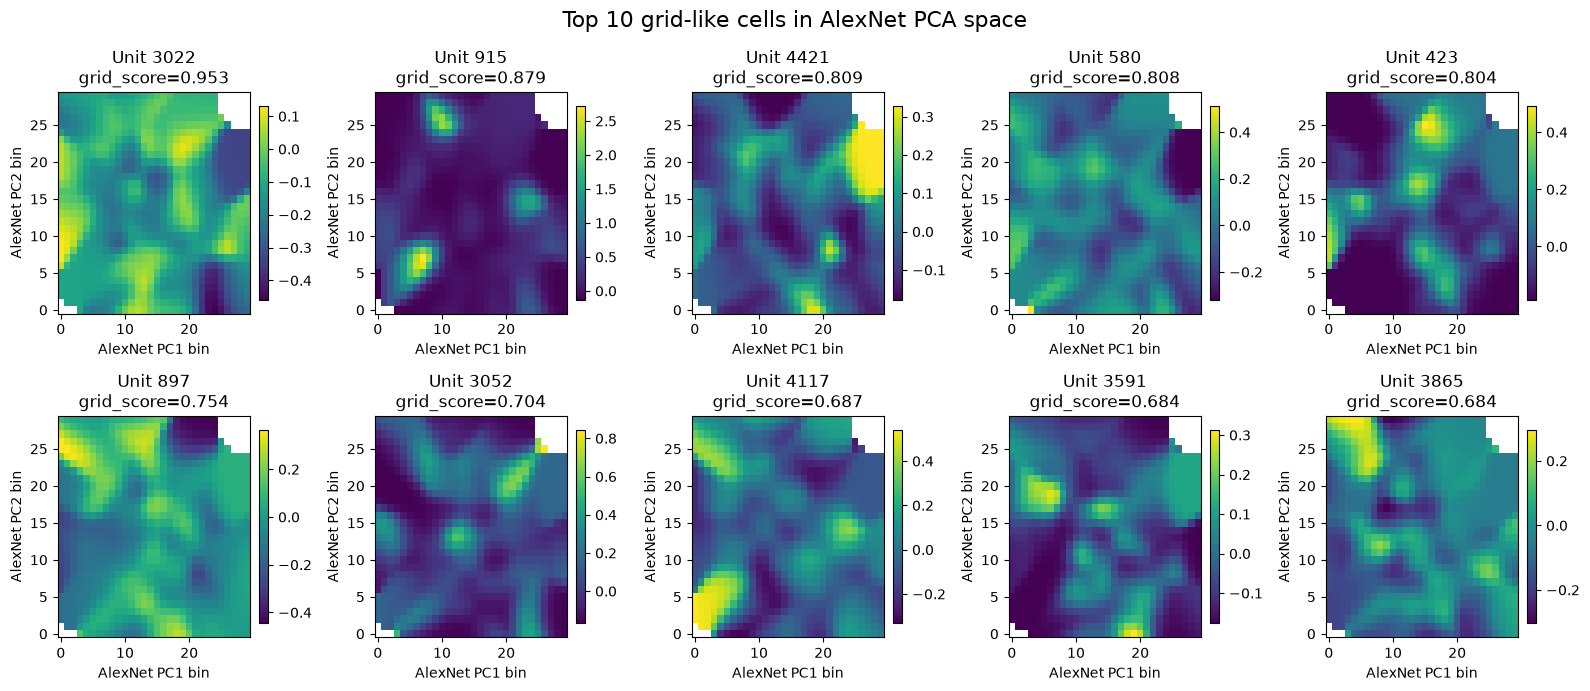

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_DIR = Path("~/Downloads/abstractRepresentationsInMTL-master").expanduser()

GRID_FP  = REPO_DIR / "alexnet_pca_grid_cells.csv"
MAP_FP   = REPO_DIR / "alexnet_pca_unit_rate_maps_long.csv"

grid_df  = pd.read_csv(GRID_FP)
map_df   = pd.read_csv(MAP_FP)

# ------------------------------------------------------------
# Pick top cells
# ------------------------------------------------------------
top_grid = (
    grid_df
    .dropna(subset=["grid_score"])
    .sort_values("grid_score", ascending=False)
    .head(10)
)

print("\nTop grid cells:")
print(top_grid[["unit_index", "grid_score", "grid_score_p"]])


# ------------------------------------------------------------
# Helper to plot rate maps
# ------------------------------------------------------------
def plot_top_rate_maps(top_df, map_df, score_col, title_prefix, out_fp=None):
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    axes = axes.ravel()

    for ax, (_, row) in zip(axes, top_df.iterrows()):
        unit = int(row["unit_index"])
        score = row[score_col]

        unit_map = map_df[map_df["unit_index"] == unit].copy()

        mat = unit_map.pivot(
            index="pca_bin_y",
            columns="pca_bin_x",
            values="rate"
        ).sort_index(ascending=True)

        im = ax.imshow(
            mat.values,
            origin="lower",
            aspect="auto"
        )

        ax.set_title(f"Unit {unit}\n{score_col}={score:.3f}")
        ax.set_xlabel("AlexNet PC1 bin")
        ax.set_ylabel("AlexNet PC2 bin")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[len(top_df):]:
        ax.axis("off")

    fig.suptitle(title_prefix, fontsize=16)
    plt.tight_layout()

    if out_fp is not None:
        plt.savefig(out_fp, dpi=300, bbox_inches="tight")
        print("Saved:", out_fp)

    plt.show()


# ------------------------------------------------------------
# Plot top 10 grid cells
# ------------------------------------------------------------
plot_top_rate_maps(
    top_grid,
    map_df,
    score_col="grid_score",
    title_prefix="Top 10 grid-like cells in AlexNet PCA space",
    out_fp=REPO_DIR / "top10_grid_cells_alexnet_pca.png"
)

Top grid cells:
      unit_index  grid_score  grid_score_p
3022        3022    0.952830      0.000999
915          915    0.879197      0.000999
4421        4421    0.808699      0.000999
580          580    0.808373      0.000999
423          423    0.803688      0.000999
897          897    0.753954      0.002997
3052        3052    0.703819      0.002997
4117        4117    0.687314      0.001998
3591        3591    0.684139      0.003996
3865        3865    0.684110      0.001998

Saved: /Users/th3253/Downloads/abstractRepresentationsInMTL-master/top10_grid_cells_autocorrelograms_enhanced.png


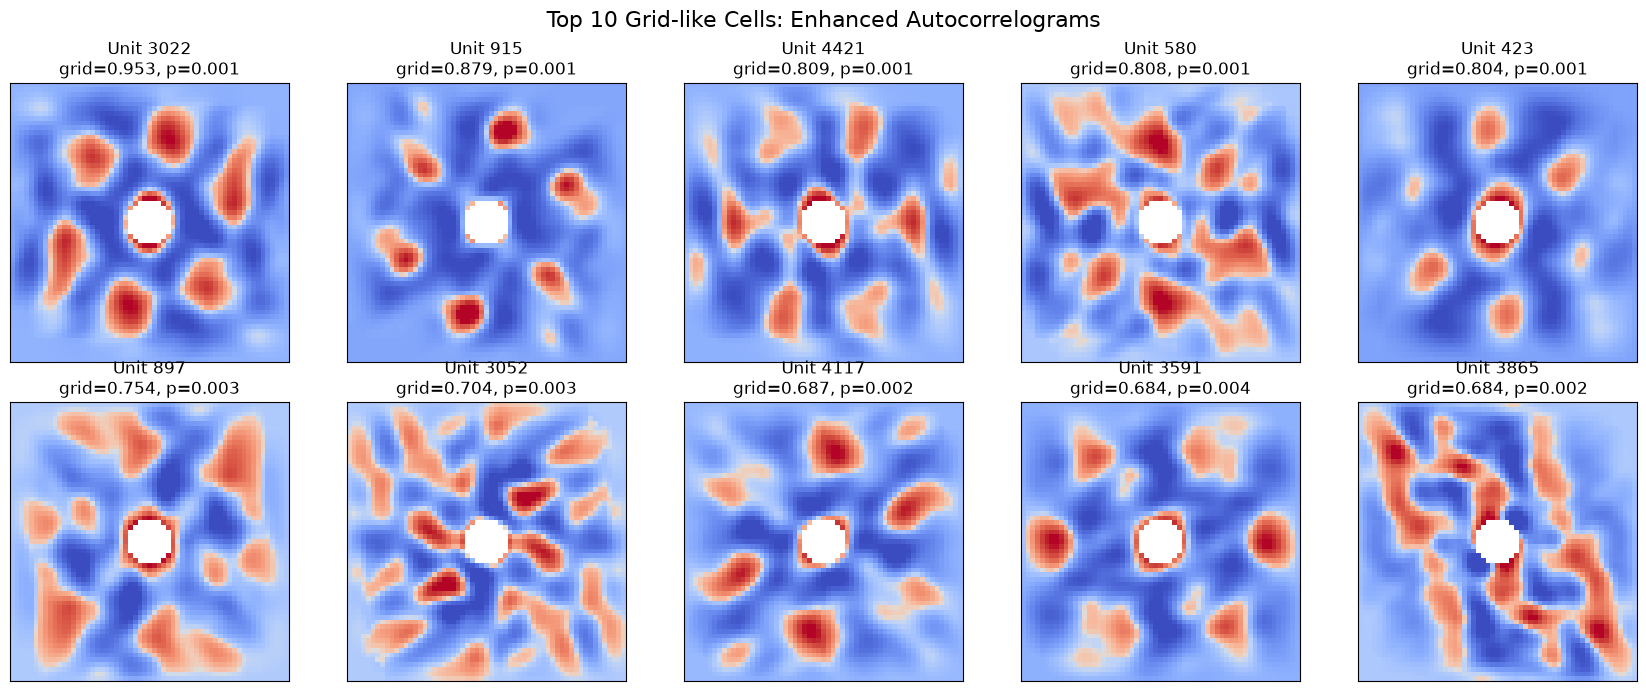

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
REPO_DIR = Path("~/Downloads/abstractRepresentationsInMTL-master").expanduser()

GRID_FP = REPO_DIR / "alexnet_pca_grid_cells.csv"
MAP_FP  = REPO_DIR / "alexnet_pca_unit_rate_maps_long.csv"

OUT_FP = REPO_DIR / "top10_grid_cells_autocorrelograms_enhanced.png"

# ============================================================
# LOAD
# ============================================================
grid_df = pd.read_csv(GRID_FP)
map_df  = pd.read_csv(MAP_FP)

# ============================================================
# HELPERS
# ============================================================
def autocorr2d(rate_map):
    """
    Normalized 2D spatial autocorrelation.
    """
    M = np.array(rate_map, dtype=float)
    valid = np.isfinite(M)

    if valid.sum() < 5:
        return None

    mean_val = np.nanmean(M)
    M = np.where(valid, M - mean_val, 0.0)

    F = np.fft.fft2(
        M,
        s=(M.shape[0] * 2 - 1, M.shape[1] * 2 - 1)
    )

    ac = np.fft.ifft2(F * np.conj(F)).real
    ac = np.fft.fftshift(ac)

    norm = np.nanmax(np.abs(ac))
    if norm <= 1e-12:
        return None

    return ac / norm


def enhance_contrast_percentile(ac, lo=2, hi=98):
    """
    Clip extreme values and rescale to [-1, 1].
    """
    vals = ac[np.isfinite(ac)]
    if len(vals) == 0:
        return ac

    vmin, vmax = np.percentile(vals, [lo, hi])
    if np.isclose(vmin, vmax):
        return ac

    ac_clip = np.clip(ac, vmin, vmax)
    ac_rescaled = 2 * (ac_clip - vmin) / (vmax - vmin + 1e-12) - 1

    return ac_rescaled


def gamma_enhance(ac, gamma=0.5):
    """
    Boost weaker structure while preserving sign.
    gamma < 1 enhances mid/low values.
    """
    return np.sign(ac) * (np.abs(ac) ** gamma)


def mask_center(ac, radius_frac=0.08):
    """
    Mask the central autocorrelation peak for visualization.
    """
    h, w = ac.shape
    yy, xx = np.indices(ac.shape)

    cy = (h - 1) / 2
    cx = (w - 1) / 2

    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    radius = radius_frac * min(h, w)

    ac2 = ac.copy()
    ac2[rr < radius] = np.nan

    return ac2


def get_rate_map_for_unit(unit, map_df):
    unit_map = map_df[map_df["unit_index"] == unit].copy()

    if unit_map.empty:
        return None

    rate_mat = (
        unit_map
        .pivot(index="pca_bin_y", columns="pca_bin_x", values="rate")
        .sort_index(ascending=True)
        .values
    )

    return rate_mat


# ============================================================
# SELECT TOP GRID CELLS
# ============================================================
top_grid = (
    grid_df
    .dropna(subset=["grid_score"])
    .sort_values("grid_score", ascending=False)
    .head(10)
)

print("Top grid cells:")
print(top_grid[["unit_index", "grid_score", "grid_score_p"]])

# ============================================================
# PLOT AUTOCORRELATIONS
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
axes = axes.ravel()

for ax, (_, row) in zip(axes, top_grid.iterrows()):

    unit = int(row["unit_index"])
    grid_score = row["grid_score"]
    grid_p = row["grid_score_p"]

    rate_mat = get_rate_map_for_unit(unit, map_df)

    if rate_mat is None:
        ax.set_title(f"Unit {unit}\nmissing map")
        ax.axis("off")
        continue

    ac = autocorr2d(rate_mat)

    if ac is None:
        ax.set_title(f"Unit {unit}\nno autocorr")
        ax.axis("off")
        continue

    # visualization-only enhancement
    ac_plot = enhance_contrast_percentile(ac, lo=2, hi=98)
    ac_plot = gamma_enhance(ac_plot, gamma=0.5)
    ac_plot = mask_center(ac_plot, radius_frac=0.08)

    im = ax.imshow(
        ac_plot,
        origin="lower",
        aspect="equal",
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    ax.set_title(
        f"Unit {unit}\n"
        f"grid={grid_score:.3f}, p={grid_p:.3f}"
    )

    ax.set_xticks([])
    ax.set_yticks([])

# hide unused axes if fewer than 10
for ax in axes[len(top_grid):]:
    ax.axis("off")

fig.suptitle(
    "Top 10 Grid-like Cells: Enhanced Autocorrelograms",
    fontsize=16
)

plt.tight_layout()
plt.savefig(OUT_FP, dpi=300, bbox_inches="tight")
print("\nSaved:", OUT_FP)

plt.show()

In [5]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd

REPO_DIR = Path("~/Downloads/abstractRepresentationsInMTL-master").expanduser()
ZVALS_FP = REPO_DIR / "zvals.mat"

GRID_FP  = REPO_DIR / "alexnet_pca_grid_cells.csv"

OUT_GRID  = REPO_DIR / "alexnet_pca_grid_cells_with_regions.csv"


def decode_matlab_string(x):
    arr = np.array(x)

    if arr.dtype.kind in {"u", "i"}:
        vals = arr.reshape(-1)
        if np.all((vals >= 0) & (vals < 256)):
            return "".join(chr(int(v)) for v in vals if int(v) != 0).strip()

    if arr.dtype.kind in {"S", "U"}:
        return "".join(arr.astype(str).reshape(-1)).strip()

    return str(arr)


def deref_string(f, ref):
    if isinstance(ref, h5py.Reference) and ref:
        return decode_matlab_string(f[ref][()])
    return ""


def read_ref_cellstr(f, dataset):
    arr = np.array(dataset)
    out = []
    for item in arr.reshape(-1):
        out.append(deref_string(f, item))
    return out


def decode_region_site_map(f):
    """
    Returns site -> region mapping, e.g.
    site_name -> AM / HC / EC / PHC
    """
    region_names = read_ref_cellstr(f, f["regions"]["name"])
    site_refs = np.array(f["regions"]["sites"]).reshape(-1)

    rows = []

    for region_name, site_ref in zip(region_names, site_refs):
        site_obj = f[site_ref]
        site_arr = np.array(site_obj).reshape(-1)

        for sr in site_arr:
            site_name = deref_string(f, sr)
            rows.append({
                "site": site_name,
                "brain_region": region_name
            })

    return pd.DataFrame(rows)


def decode_cluster_labels_from_zvals(f):
    """
    zvals is shape (stimuli, units), so unit_index = column index.
    cluster_lookup appears to store cluster labels per unit/site.
    We decode all likely string refs from #refs# and keep labels that look like
    recording-site / cluster labels rather than stimulus names.
    """
    n_units = f["zvals"].shape[1]

    # Try the simple route first: cluster_lookup may be object refs in some files.
    cl = f["cluster_lookup"]
    arr = np.array(cl)

    labels = []

    if arr.dtype == object:
        for item in arr.reshape(-1):
            labels.append(deref_string(f, item))

    # Your file has uint32 weirdness, so fallback: scan #refs# strings.
    # We keep non-stimulus-looking strings likely to be site/cluster identifiers.
    if len(labels) != n_units:
        all_strings = []

        for key in f["#refs#"].keys():
            obj = f["#refs#"][key]
            if isinstance(obj, h5py.Dataset):
                try:
                    s = decode_matlab_string(obj[()])
                    if s:
                        all_strings.append(s)
                except Exception:
                    pass

        # Remove stimulus/category-looking labels like manmade_food_2.
        # Keep strings that contain site/region-like prefixes.
        keep = []
        for s in all_strings:
            sl = s.lower()
            if any(tok in sl for tok in ["am", "hc", "ec", "phc", "amy", "hip", "entorh", "para"]):
                keep.append(s)

        # de-duplicate while preserving order
        seen = set()
        labels = []
        for s in keep:
            if s not in seen:
                labels.append(s)
                seen.add(s)

    if len(labels) < n_units:
        print(f"WARNING: decoded only {len(labels)} labels for {n_units} units.")
    elif len(labels) > n_units:
        labels = labels[:n_units]

    return pd.DataFrame({
        "unit_index": np.arange(len(labels)),
        "cluster_label": labels
    })


def assign_region_from_site(unit_df, site_region_df):
    """
    Match each unit cluster label to a region using site names.
    """
    site_region_df = site_region_df.copy()
    site_region_df["site_lower"] = site_region_df["site"].astype(str).str.lower()

    def get_region(label):
        lab = str(label).lower()

        matches = site_region_df[
            site_region_df["site_lower"].apply(lambda s: s != "" and s in lab)
        ]

        if len(matches) > 0:
            return matches.iloc[0]["brain_region"], matches.iloc[0]["site"]

        return np.nan, np.nan

    mapped = unit_df["cluster_label"].apply(get_region)
    unit_df["brain_region"] = [x[0] for x in mapped]
    unit_df["matched_site"] = [x[1] for x in mapped]

    return unit_df


with h5py.File(ZVALS_FP, "r") as f:
    site_region_df = decode_region_site_map(f)
    unit_region_df = decode_cluster_labels_from_zvals(f)

unit_region_df = assign_region_from_site(unit_region_df, site_region_df)

print("\nSite → region map:")
print(site_region_df)

print("\nDecoded unit labels preview:")
print(unit_region_df.head(20))

print("\nAll unit region counts:")
print(unit_region_df["brain_region"].value_counts(dropna=False))


grid_df  = pd.read_csv(GRID_FP)

grid_reg  = grid_df.merge(unit_region_df, on="unit_index", how="left")

grid_reg.to_csv(OUT_GRID, index=False)

print("\nSaved:")
print(OUT_GRID)


print("\nGrid-cell counts by region:")
print(
    grid_reg
    .query("grid_cell == True")
    ["brain_region"]
    .value_counts(dropna=False)
)

print("\nTop 20 grid cells:")
print(
    grid_reg
    .sort_values("grid_score", ascending=False)
    [["unit_index", "brain_region", "matched_site", "cluster_label",
      "grid_score", "grid_score_p"]]
    .head(20)
)


Site → region map:
    site brain_region
0     LA           AM
1     RA           AM
2    LAH           HC
3    RAH           HC
4    LMH           HC
5    RMH           HC
6    LPH           HC
7    RPH           HC
8    LEC           EC
9    REC           EC
10  LPHC          PHC
11  RPHC          PHC

Decoded unit labels preview:
    unit_index                                      cluster_label  \
0            0                                                 AM   
1            1                                                REC   
2            2                                                LEC   
3            3                                                PHC   
4            4                                               RPHC   
5            5                                                 HC   
6            6                                                 EC   
7            7                                               LPHC   
8            8  [[<HDF5 object reference> <

In [6]:
sess = m["sess"]

print("sess fields:")
print(sess._fieldnames)

for field in sess._fieldnames:
    val = getattr(sess, field)
    print("\n---", field, "---")
    print(type(val))
    print("shape:", np.shape(val))
    if np.size(val) < 20:
        print(val)
    else:
        print("preview:", np.ravel(val)[:10])

NameError: name 'm' is not defined

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io as sio

REPO_DIR = Path("~/Downloads/abstractRepresentationsInMTL-master").expanduser()

UNIT_DESC_FP = REPO_DIR / "unit_descriptives.mat"
GRID_FP  = REPO_DIR / "alexnet_pca_grid_cells.csv"

OUT_GRID  = REPO_DIR / "alexnet_pca_grid_cells_with_block_regions.csv"

# ------------------------------------------------------------
# Load region counts
# ------------------------------------------------------------
m = sio.loadmat(UNIT_DESC_FP, squeeze_me=True, struct_as_record=False)

region_names = ["AM", "HC", "EC", "PHC"]
region_counts = np.array(m["ntot"]).astype(int)

print("Region counts from unit_descriptives.mat:")
for r, n in zip(region_names, region_counts):
    print(r, n)

print("Sum labeled:", region_counts.sum())

# zvals has 5033 units based on your output
N_UNITS = 5033

labels = []
for r, n in zip(region_names, region_counts):
    labels.extend([r] * n)

if len(labels) < N_UNITS:
    labels.extend(["UNKNOWN"] * (N_UNITS - len(labels)))

labels = labels[:N_UNITS]

region_df = pd.DataFrame({
    "unit_index": np.arange(N_UNITS),
    "brain_region": labels
})

print("\nAll-unit region counts:")
print(region_df["brain_region"].value_counts())

# ------------------------------------------------------------
# Merge with grid file
# ------------------------------------------------------------
grid_df  = pd.read_csv(GRID_FP)

grid_reg  = grid_df.merge(region_df, on="unit_index", how="left")

grid_reg.to_csv(OUT_GRID, index=False)

print("\nSaved:")
print(OUT_GRID)

# ------------------------------------------------------------
# Counts by region
# ------------------------------------------------------------

print("\nGrid-cell counts by region:")
print(
    grid_reg
    .query("grid_cell == True")
    ["brain_region"]
    .value_counts(dropna=False)
)

print("\nTop 20 grid cells:")
print(
    grid_reg
    .sort_values("grid_score", ascending=False)
    [["unit_index", "brain_region", "grid_score", "grid_score_p"]]
    .head(20)
)

Region counts from unit_descriptives.mat:
AM 1392
HC 1863
EC 828
PHC 831
Sum labeled: 4914

All-unit region counts:
brain_region
HC         1863
AM         1392
PHC         831
EC          828
UNKNOWN     119
Name: count, dtype: int64

Saved:
/Users/th3253/Downloads/abstractRepresentationsInMTL-master/alexnet_pca_grid_cells_with_block_regions.csv

Grid-cell counts by region:
brain_region
HC         91
AM         63
EC         58
PHC        40
UNKNOWN     5
Name: count, dtype: int64

Top 20 grid cells:
      unit_index brain_region  grid_score  grid_score_p
3022        3022           HC    0.952830      0.000999
915          915           AM    0.879197      0.000999
4421        4421          PHC    0.808699      0.000999
580          580           AM    0.808373      0.000999
423          423           AM    0.803688      0.000999
897          897           AM    0.753954      0.002997
3052        3052           HC    0.703819      0.002997
4117        4117          PHC    0.687314    

Saved: /Users/th3253/Downloads/abstractRepresentationsInMTL-master/alexnet_tsne_space_with_images.png


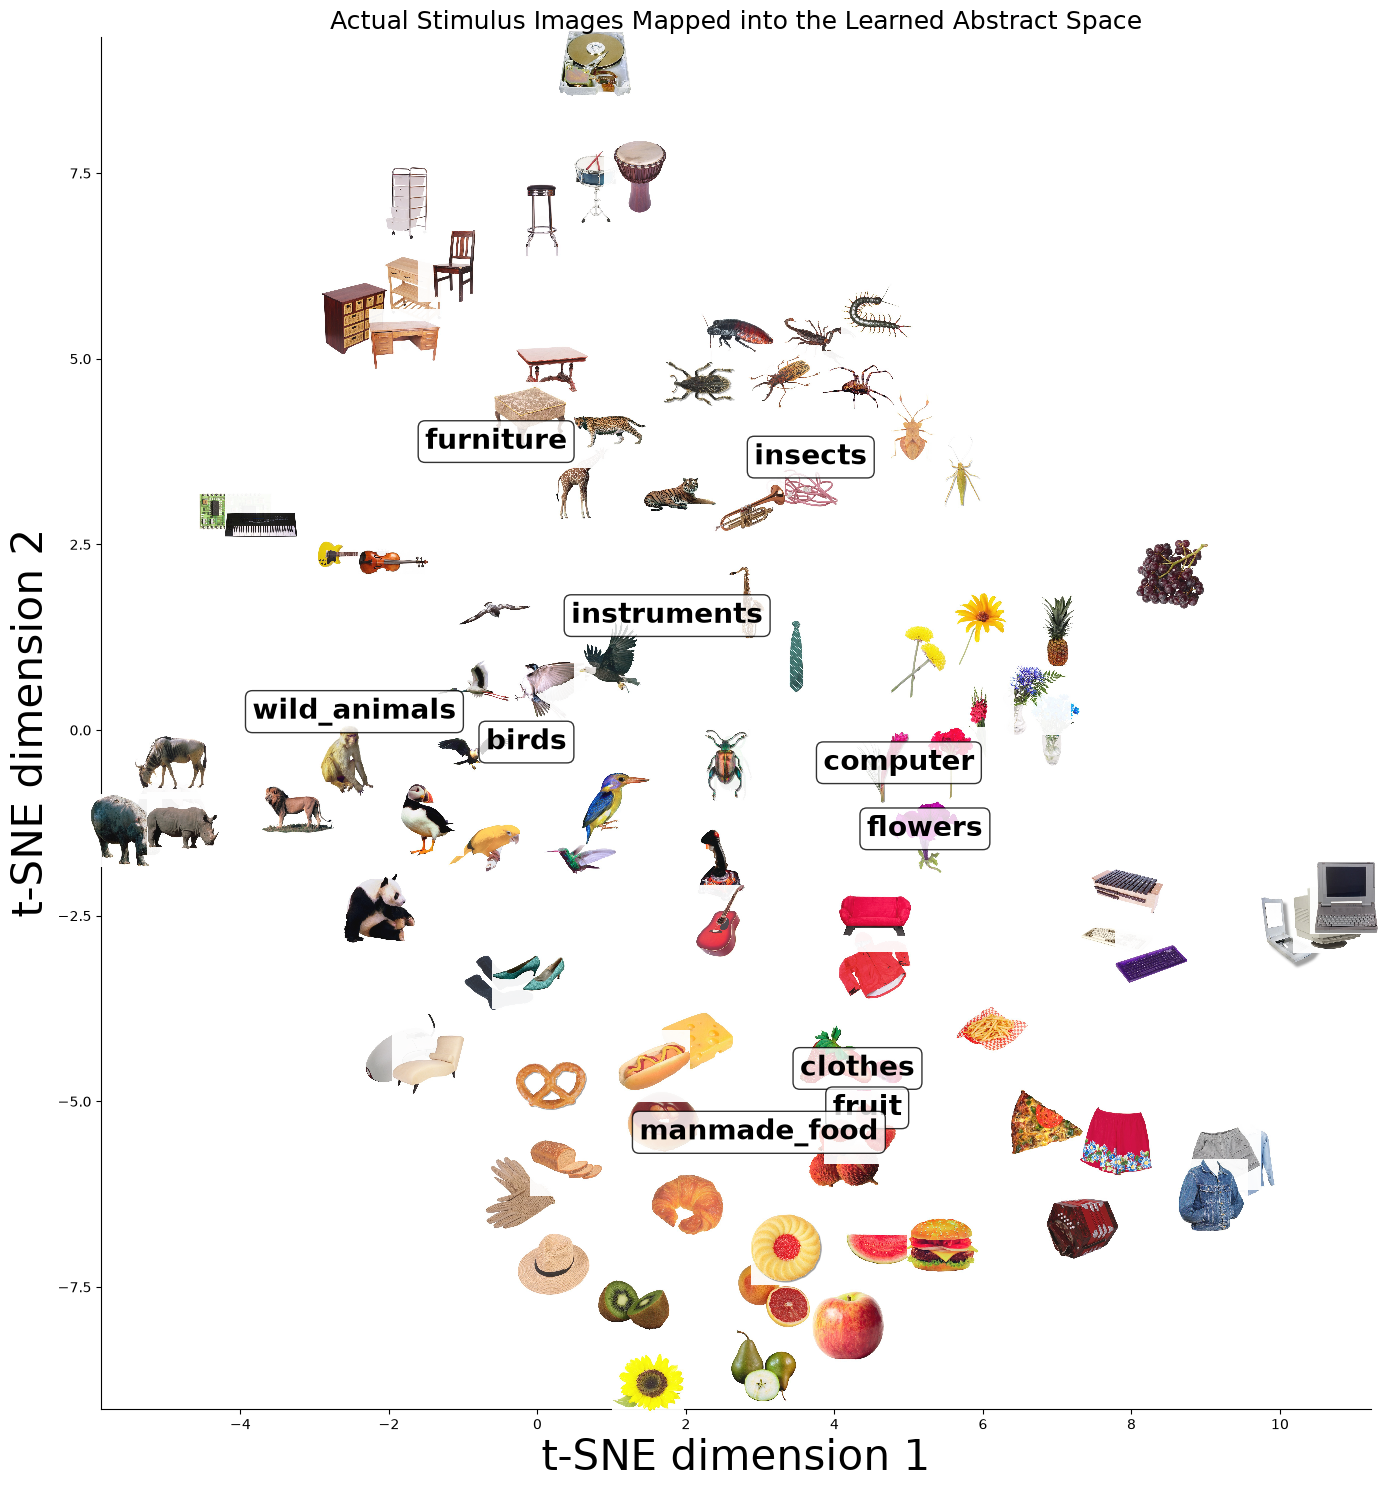

In [8]:
# ============================================================
# PLOT THE ABSTRACT SPACE WITH THE ACTUAL STIMULUS IMAGES
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

REPO_DIR = Path("~/Downloads/abstractRepresentationsInMTL-master").expanduser()
SPACE_FP = REPO_DIR / "alexnet_10way_tsne_stimulus_space_2d.csv"
OUT_FP = REPO_DIR / "alexnet_tsne_space_with_images.png"

# Main appearance controls
THUMBNAIL_ZOOM = 0.13       # decrease if images overlap too much
FIGSIZE = (18, 15)
SHOW_CATEGORY_LABELS = False
LABEL_CENTROIDS = True
POINT_ALPHA = 0.18
IMAGE_ALPHA = 0.95

space_df = pd.read_csv(SPACE_FP)

required_cols = {"bottleneck_1", "bottleneck_2", "image_path"}
missing = required_cols - set(space_df.columns)
if missing:
    raise ValueError(f"Missing required columns in {SPACE_FP.name}: {sorted(missing)}")

# Use the most informative category column available.
category_candidates = [
    "category_name",
    "behavioral_response_category",
    "predicted_category"
]
category_col = next(
    (col for col in category_candidates if col in space_df.columns),
    None
)

space_df = space_df.dropna(
    subset=["bottleneck_1", "bottleneck_2", "image_path"]
).copy()

# Resolve image paths robustly.
def resolve_image_path(raw_path):
    p = Path(str(raw_path)).expanduser()

    if p.exists():
        return p

    # Handles paths saved relative to the repository.
    p_repo = REPO_DIR / p
    if p_repo.exists():
        return p_repo

    # Handles CSVs moved between machines when only the filename is stable.
    matches = list(REPO_DIR.rglob(p.name))
    if len(matches) == 1:
        return matches[0]

    return None

space_df["resolved_image_path"] = space_df["image_path"].apply(resolve_image_path)

n_missing = space_df["resolved_image_path"].isna().sum()
if n_missing:
    print(f"Warning: could not locate {n_missing} image(s); those stimuli will remain as points.")

fig, ax = plt.subplots(figsize=FIGSIZE)

# Faint points make the overall geometry visible behind the thumbnails.
if category_col is not None:
    categories = sorted(space_df[category_col].dropna().astype(str).unique())
    cmap = plt.get_cmap("tab10", max(len(categories), 1))
    category_colors = {
        cat: cmap(i % cmap.N)
        for i, cat in enumerate(categories)
    }

    for cat in categories:
        d = space_df[space_df[category_col].astype(str) == cat]
        ax.scatter(
            d["bottleneck_1"],
            d["bottleneck_2"],
            s=35,
            alpha=POINT_ALPHA,
            label=cat,
            color=category_colors[cat],
            zorder=1
        )
else:
    ax.scatter(
        space_df["bottleneck_1"],
        space_df["bottleneck_2"],
        s=35,
        alpha=POINT_ALPHA,
        zorder=1
    )

# Put each actual image at its t-SNE coordinate.
for _, row in space_df.iterrows():
    image_fp = row["resolved_image_path"]
    if image_fp is None:
        continue

    try:
        with Image.open(image_fp) as im:
            im = im.convert("RGB")
            image_array = np.asarray(im)

        image_box = OffsetImage(
            image_array,
            zoom=THUMBNAIL_ZOOM,
            alpha=IMAGE_ALPHA
        )
        artist = AnnotationBbox(
            image_box,
            (row["bottleneck_1"], row["bottleneck_2"]),
            frameon=False,
            pad=0,
            zorder=3
        )
        ax.add_artist(artist)

        if SHOW_CATEGORY_LABELS and category_col is not None:
            ax.annotate(
                str(row[category_col]),
                (row["bottleneck_1"], row["bottleneck_2"]),
                xytext=(0, -18),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=6,
                alpha=0.75,
                zorder=4
            )

    except Exception as exc:
        print(f"Could not plot {image_fp}: {exc}")

# Optionally label the center of each category cluster.
if LABEL_CENTROIDS and category_col is not None:
    centroids = (
        space_df
        .dropna(subset=[category_col])
        .groupby(category_col, as_index=False)[["bottleneck_1", "bottleneck_2"]]
        .mean()
    )

    for _, row in centroids.iterrows():
        ax.text(
            row["bottleneck_1"],
            row["bottleneck_2"],
            str(row[category_col]),
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="black",
                alpha=0.80
            ),
            zorder=5
        )

ax.set_title("Actual Stimulus Images Mapped into the Learned Abstract Space", fontsize=18)
ax.set_xlabel("t-SNE dimension 1", fontsize=30)
ax.set_ylabel("t-SNE dimension 2", fontsize=30)
ax.set_aspect("equal", adjustable="box")
pad = 0.02
xmin = space_df["bottleneck_1"].min()
xmax = space_df["bottleneck_1"].max()
ymin = space_df["bottleneck_2"].min()
ymax = space_df["bottleneck_2"].max()
xrange = xmax - xmin
yrange = ymax - ymin

ax.set_xlim(xmin - pad*xrange, xmax + pad*xrange)
ax.set_ylim(ymin - pad*yrange, ymax + pad*yrange)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_FP, dpi=300, bbox_inches="tight")
print("Saved:", OUT_FP)
plt.show()


Selected waveform matrix: (1917, 64)


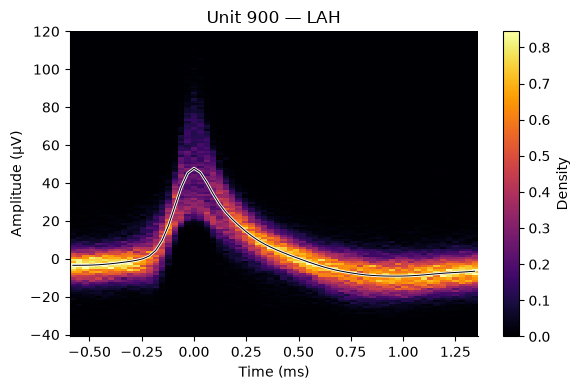

In [9]:
from pathlib import Path
import numpy as np
import scipy.io as sio
import h5py


DATA_DIR = Path(
    "~/Downloads/abstractRepresentationsInMTL-master"
).expanduser()


def load_mat_variable(file_path, variable):
    """
    Load a variable from either a standard MATLAB file
    or a MATLAB v7.3/HDF5 file.
    """

    file_path = Path(file_path)

    try:
        mat = sio.loadmat(
            file_path,
            squeeze_me=True,
            struct_as_record=False
        )

        if variable not in mat:
            raise KeyError(
                f"{variable!r} not found in {file_path.name}. "
                f"Variables: {[k for k in mat if not k.startswith('__')]}"
            )

        return np.asarray(mat[variable])

    except NotImplementedError:
        pass

    with h5py.File(file_path, "r") as h5:
        if variable not in h5:
            raise KeyError(
                f"{variable!r} not found in {file_path.name}. "
                f"Variables: {list(h5.keys())}"
            )

        return np.asarray(h5[variable])


def load_unit_spikes(times_file, cluster_id):
    """
    Load all raw spike-waveform snippets for one unit.

    Returns
    -------
    unit_spikes : ndarray, shape (n_spikes, n_samples)
        Waveforms for spikes assigned to cluster_id.
    """

    times_file = Path(times_file).expanduser()

    spikes = load_mat_variable(
        times_file,
        "spikes"
    )

    cluster_class = load_mat_variable(
        times_file,
        "cluster_class"
    )

    spikes = np.asarray(spikes, dtype=float)
    cluster_class = np.asarray(cluster_class)

    # MATLAB v7.3 arrays can sometimes arrive transposed.
    if spikes.ndim != 2:
        raise ValueError(
            f"'spikes' should be 2D, but shape is {spikes.shape}"
        )

    if cluster_class.ndim == 1:
        cluster_ids = cluster_class
    else:
        # Usually rows are spikes and column 1 is cluster ID.
        if cluster_class.shape[0] == spikes.shape[0]:
            cluster_ids = cluster_class[:, 0]

        # Handle an HDF5-transposed matrix.
        elif cluster_class.shape[1] == spikes.shape[0]:
            cluster_ids = cluster_class[0, :]

        else:
            raise ValueError(
                "Could not align cluster_class with spikes.\n"
                f"spikes shape: {spikes.shape}\n"
                f"cluster_class shape: {cluster_class.shape}"
            )

    # Also handle transposed spikes: samples × spikes.
    if spikes.shape[0] != cluster_ids.size:
        if spikes.shape[1] == cluster_ids.size:
            spikes = spikes.T
        else:
            raise ValueError(
                "Neither spike axis matches cluster_class.\n"
                f"spikes shape: {spikes.shape}\n"
                f"number of cluster labels: {cluster_ids.size}"
            )

    selected = (
        np.asarray(cluster_ids).astype(int) ==
        int(cluster_id)
    )

    unit_spikes = spikes[selected, :]

    if unit_spikes.shape[0] == 0:
        raise ValueError(
            f"No spikes found for cluster {cluster_id} "
            f"in {times_file.name}"
        )

    return unit_spikes

import matplotlib.pyplot as plt


def density_plot(
    ax,
    spikes,
    idx=None,
    donorm=True,
    cmap="inferno",
    sampling_rate_hz=2**15,
    pre_samples=19,
    n_ybins=150,
    show_mean=True
):
    """
    Temperature-scaled spike-waveform density plot.

    Parameters
    ----------
    spikes : ndarray, shape (n_spikes, n_samples)
        Raw waveform snippets, expected in microvolts.

    idx : array-like or None
        Optional subset of spike rows.

    donorm : bool
        Divide density by its maximum.

    sampling_rate_hz : float
        Original MATLAB code assumes 32768 Hz.

    pre_samples : int
        MATLAB time vector begins at sample -19.
    """

    wavs = np.asarray(
        spikes,
        dtype=float
    )

    if wavs.ndim == 1:
        wavs = wavs[None, :]

    if idx is not None:
        wavs = wavs[
            np.asarray(idx)
        ]

    # Remove waveforms containing no usable values.
    wavs = wavs[
        np.isfinite(wavs).any(axis=1)
    ]

    if wavs.shape[0] == 0:
        ax.text(
            0.5,
            0.5,
            "No waveform data",
            ha="center",
            va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        return None

    n_spikes, n_samples = wavs.shape

    # MATLAB:
    # xvals = [-19:44] * 1000 / (2^15)
    xvals_ms = (
        (
            np.arange(n_samples) -
            pre_samples
        )
        * 1000 /
        sampling_rate_hz
    )

    lower = np.floor(
        np.nanmin(wavs)
    )

    upper = np.ceil(
        np.nanmax(wavs)
    )

    if upper <= lower:
        upper = lower + 1

    y_edges = np.linspace(
        lower,
        upper,
        n_ybins + 1
    )

    density = np.zeros(
        (n_ybins, n_samples),
        dtype=float
    )

    for sample_i in range(n_samples):
        values = wavs[:, sample_i]
        values = values[np.isfinite(values)]

        density[:, sample_i], _ = np.histogram(
            values,
            bins=y_edges
        )

    if donorm:
        max_density = np.nanmax(density)

        if max_density > 0:
            density /= max_density

    # Same high-density clipping as the MATLAB function.
    cutoff = 5 * np.nanstd(
        density.ravel()
    )

    if np.isfinite(cutoff) and cutoff > 0:
        density[density > cutoff] = cutoff

    sample_duration_ms = (
        1000 / sampling_rate_hz
    )

    x_edges = np.concatenate([
        xvals_ms - sample_duration_ms / 2,
        [xvals_ms[-1] + sample_duration_ms / 2]
    ])

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        density,
        cmap=cmap,
        shading="auto"
    )

    if show_mean:
        mean_spike = np.nanmean(
            wavs,
            axis=0
        )

        # Black-and-white overlay remains visible across
        # both dark and bright portions of the heatmap.
        ax.plot(
            xvals_ms,
            mean_spike,
            color="white",
            linewidth=2.0
        )

        ax.plot(
            xvals_ms,
            mean_spike,
            color="black",
            linewidth=0.7
        )

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")

    ax.set_xlim(
        x_edges[0],
        x_edges[-1]
    )

    ax.set_ylim(
        y_edges[0],
        y_edges[-1]
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    return mesh

example_times_file = (
    DATA_DIR /
    "033e06timesCSC10.mat"
)

example_spikes = load_unit_spikes(
    times_file=example_times_file,
    cluster_id=1
)

print(
    "Selected waveform matrix:",
    example_spikes.shape
)

fig, ax = plt.subplots(
    figsize=(6, 4)
)

mesh = density_plot(
    ax=ax,
    spikes=example_spikes,
    cmap="inferno"
)

ax.set_title(
    "Unit 900 — LAH"
)

if mesh is not None:
    cbar = fig.colorbar(
        mesh,
        ax=ax
    )
    cbar.set_label("Density")

plt.tight_layout()
plt.show()

Best grid unit: 3022
Grid score: 0.9528302144744848
Activation matrix shape: (5033, 1000)
Number of stimuli: 100
Assuming 10 presentations per stimulus.
Trial rates shape: (1000,)
Stimulus rates shape: (100,)
Stimulus-level rate range: -0.8982078996946774 to 0.9379056466039423


/var/folders/k4/6ldt4z5j3qs95xyx5vzndvww8htdq8/T/ipykernel_44110/2837751665.py:398: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/th3253/Downloads/abstractRepresentationsInMTL-master/best_grid_cell_firing_over_stimulus_space.png


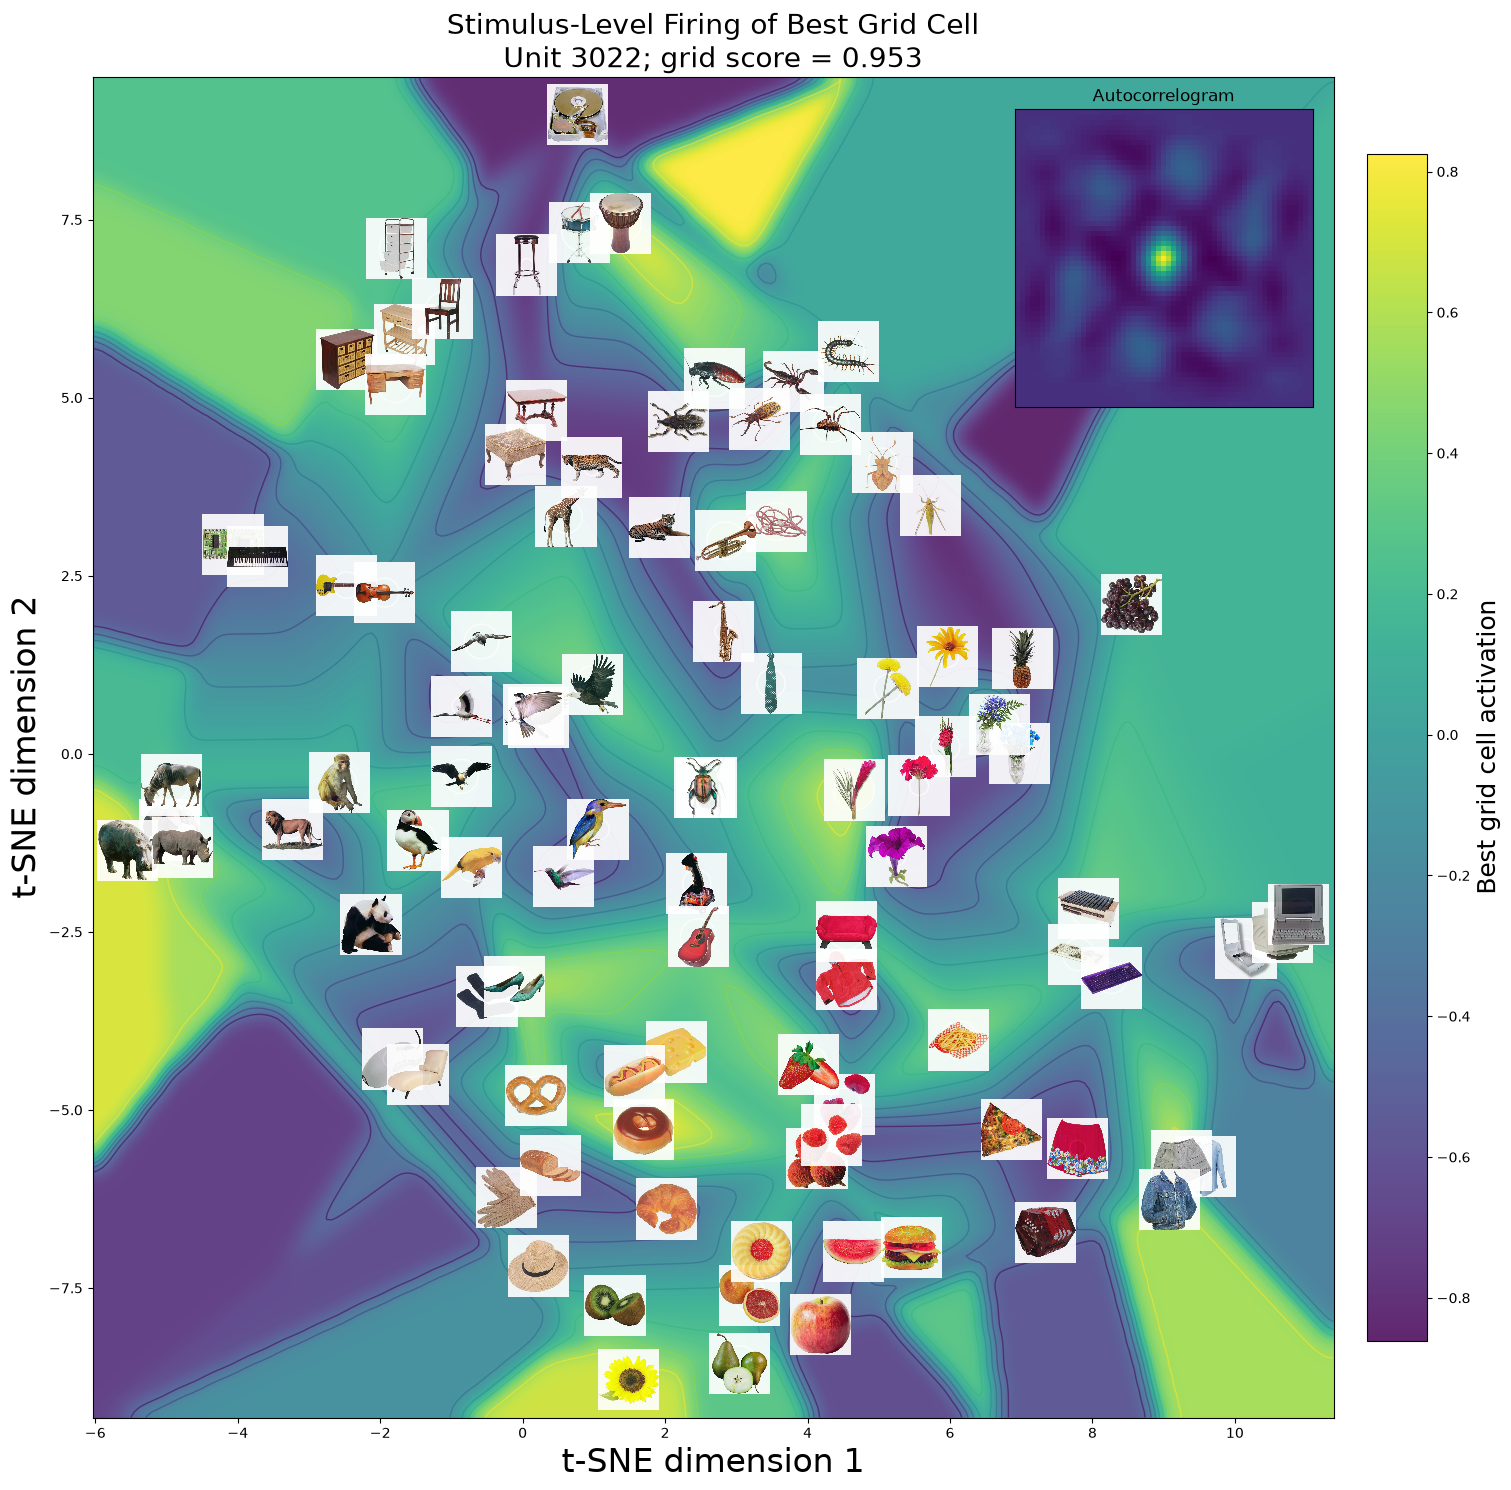

In [15]:
# ============================================================
# BEST GRID CELL FIRING OVER STIMULUS GEOMETRY
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


REPO_DIR = Path(
    "~/Downloads/abstractRepresentationsInMTL-master"
).expanduser()

SPACE_FP = REPO_DIR / "alexnet_10way_tsne_stimulus_space_2d.csv"
NEURAL_FP = REPO_DIR / "zvals_trials_units_by_trials.npy"
OUT_FP = REPO_DIR / "best_grid_cell_firing_over_stimulus_space.png"


# ------------------------------------------------------------
# Load stimulus geometry
# ------------------------------------------------------------
space_df = pd.read_csv(SPACE_FP)

required_cols = {
    "bottleneck_1",
    "bottleneck_2",
    "image_path"
}

missing = required_cols - set(space_df.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}"
    )


# ------------------------------------------------------------
# Select best grid cell
# ------------------------------------------------------------
best_grid_row = (
    grid_df
    .dropna(subset=["grid_score"])
    .sort_values("grid_score", ascending=False)
    .iloc[0]
)

best_unit = int(best_grid_row["unit_index"])
best_grid_score = float(best_grid_row["grid_score"])

print("Best grid unit:", best_unit)
print("Grid score:", best_grid_score)


# ------------------------------------------------------------
# Load units × trials activation matrix
# ------------------------------------------------------------
activation_matrix = np.load(NEURAL_FP)

print("Activation matrix shape:", activation_matrix.shape)
print("Number of stimuli:", len(space_df))

if best_unit >= activation_matrix.shape[0]:
    raise IndexError(
        f"Unit {best_unit} is outside the matrix."
    )

trial_rates = np.asarray(
    activation_matrix[best_unit, :],
    dtype=float
)

n_stimuli = len(space_df)
n_trials = len(trial_rates)

if n_trials % n_stimuli != 0:
    raise ValueError(
        f"{n_trials} trials cannot be divided evenly across "
        f"{n_stimuli} stimuli."
    )

repetitions_per_stimulus = n_trials // n_stimuli

print(
    f"Assuming {repetitions_per_stimulus} "
    "presentations per stimulus."
)


# ------------------------------------------------------------
# Average repeated presentations
# Assumes order:
# stim 1...100, repeated across 10 passes
# ------------------------------------------------------------
stimulus_rates = np.nanmean(
    trial_rates.reshape(
        repetitions_per_stimulus,
        n_stimuli
    ),
    axis=0
)

space_df["best_grid_rate"] = stimulus_rates

print("Trial rates shape:", trial_rates.shape)
print("Stimulus rates shape:", stimulus_rates.shape)
print(
    "Stimulus-level rate range:",
    np.nanmin(stimulus_rates),
    "to",
    np.nanmax(stimulus_rates)
)


# ------------------------------------------------------------
# Remove invalid rows
# ------------------------------------------------------------
space_df = space_df.dropna(
    subset=[
        "bottleneck_1",
        "bottleneck_2",
        "best_grid_rate",
        "image_path"
    ]
).copy()


# ------------------------------------------------------------
# Resolve image paths
# ------------------------------------------------------------
def resolve_image_path(raw_path):
    p = Path(str(raw_path)).expanduser()

    if p.exists():
        return p

    p_repo = REPO_DIR / p

    if p_repo.exists():
        return p_repo

    matches = list(REPO_DIR.rglob(p.name))

    if len(matches) == 1:
        return matches[0]

    return None


space_df["resolved_image_path"] = (
    space_df["image_path"].apply(resolve_image_path)
)


# ------------------------------------------------------------
# Build smooth rate surface
# ------------------------------------------------------------
x = space_df["bottleneck_1"].to_numpy(dtype=float)
y = space_df["bottleneck_2"].to_numpy(dtype=float)
rates = space_df["best_grid_rate"].to_numpy(dtype=float)

xmin, xmax = np.nanmin(x), np.nanmax(x)
ymin, ymax = np.nanmin(y), np.nanmax(y)

x_pad = 0.03 * (xmax - xmin)
y_pad = 0.03 * (ymax - ymin)

grid_x, grid_y = np.meshgrid(
    np.linspace(
        xmin - x_pad,
        xmax + x_pad,
        250
    ),
    np.linspace(
        ymin - y_pad,
        ymax + y_pad,
        250
    )
)

rate_surface = griddata(
    points=np.column_stack([x, y]),
    values=rates,
    xi=(grid_x, grid_y),
    method="linear"
)

nearest_surface = griddata(
    points=np.column_stack([x, y]),
    values=rates,
    xi=(grid_x, grid_y),
    method="nearest"
)

rate_surface = np.where(
    np.isfinite(rate_surface),
    rate_surface,
    nearest_surface
)

rate_surface = gaussian_filter(
    rate_surface,
    sigma=2
)


# ------------------------------------------------------------
# Original rate map and autocorrelogram
# ------------------------------------------------------------
best_rate_map = get_rate_map_for_unit(
    best_unit,
    map_df
)

best_autocorr = autocorr2d(
    best_rate_map
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(18, 15)
)

heat = ax.imshow(
    rate_surface,
    extent=[
        grid_x.min(),
        grid_x.max(),
        grid_y.min(),
        grid_y.max()
    ],
    origin="lower",
    aspect="auto",
    interpolation="bilinear",
    alpha=0.85,
    zorder=0
)


# Exact stimulus firing-rate halos
rate_min = np.nanmin(rates)
rate_max = np.nanmax(rates)

normalized_rates = (
    (rates - rate_min) /
    (rate_max - rate_min + 1e-12)
)

halo_sizes = 80 + 850 * normalized_rates

ax.scatter(
    x,
    y,
    c=rates,
    s=halo_sizes,
    alpha=0.75,
    edgecolors="white",
    linewidths=1,
    zorder=2
)


# Rate contours
levels = np.linspace(
    np.nanpercentile(rate_surface, 20),
    np.nanpercentile(rate_surface, 95),
    7
)

ax.contour(
    grid_x,
    grid_y,
    rate_surface,
    levels=levels,
    linewidths=1,
    alpha=0.55,
    zorder=1
)


# Stimulus images
for _, row in space_df.iterrows():
    image_fp = row["resolved_image_path"]

    if image_fp is None:
        continue

    try:
        with Image.open(image_fp) as im:
            image_array = np.asarray(
                im.convert("RGB")
            )

        image_box = OffsetImage(
            image_array,
            zoom=0.11,
            alpha=0.92
        )

        artist = AnnotationBbox(
            image_box,
            (
                row["bottleneck_1"],
                row["bottleneck_2"]
            ),
            frameon=False,
            pad=0,
            zorder=4
        )

        ax.add_artist(artist)

    except Exception as exc:
        print(
            f"Could not plot {image_fp}: {exc}"
        )


# Autocorrelogram inset
if best_autocorr is not None:
    inset_ax = inset_axes(
        ax,
        width="24%",
        height="24%",
        loc="upper right",
        borderpad=1.5
    )

    inset_ax.imshow(
        best_autocorr,
        origin="lower",
        interpolation="nearest"
    )

    inset_ax.set_title(
        "Autocorrelogram",
        fontsize=12
    )

    inset_ax.set_xticks([])
    inset_ax.set_yticks([])


# Labels
cbar = fig.colorbar(
    heat,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "Best grid cell activation",
    fontsize=18
)

ax.set_title(
    "Stimulus-Level Firing of Best Grid Cell\n"
    f"Unit {best_unit}; grid score = {best_grid_score:.3f}",
    fontsize=20
)

ax.set_xlabel(
    "t-SNE dimension 1",
    fontsize=24
)

ax.set_ylabel(
    "t-SNE dimension 2",
    fontsize=24
)

ax.set_xlim(
    xmin - x_pad,
    xmax + x_pad
)

ax.set_ylim(
    ymin - y_pad,
    ymax + y_pad
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

plt.tight_layout()

plt.savefig(
    OUT_FP,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", OUT_FP)

plt.show()

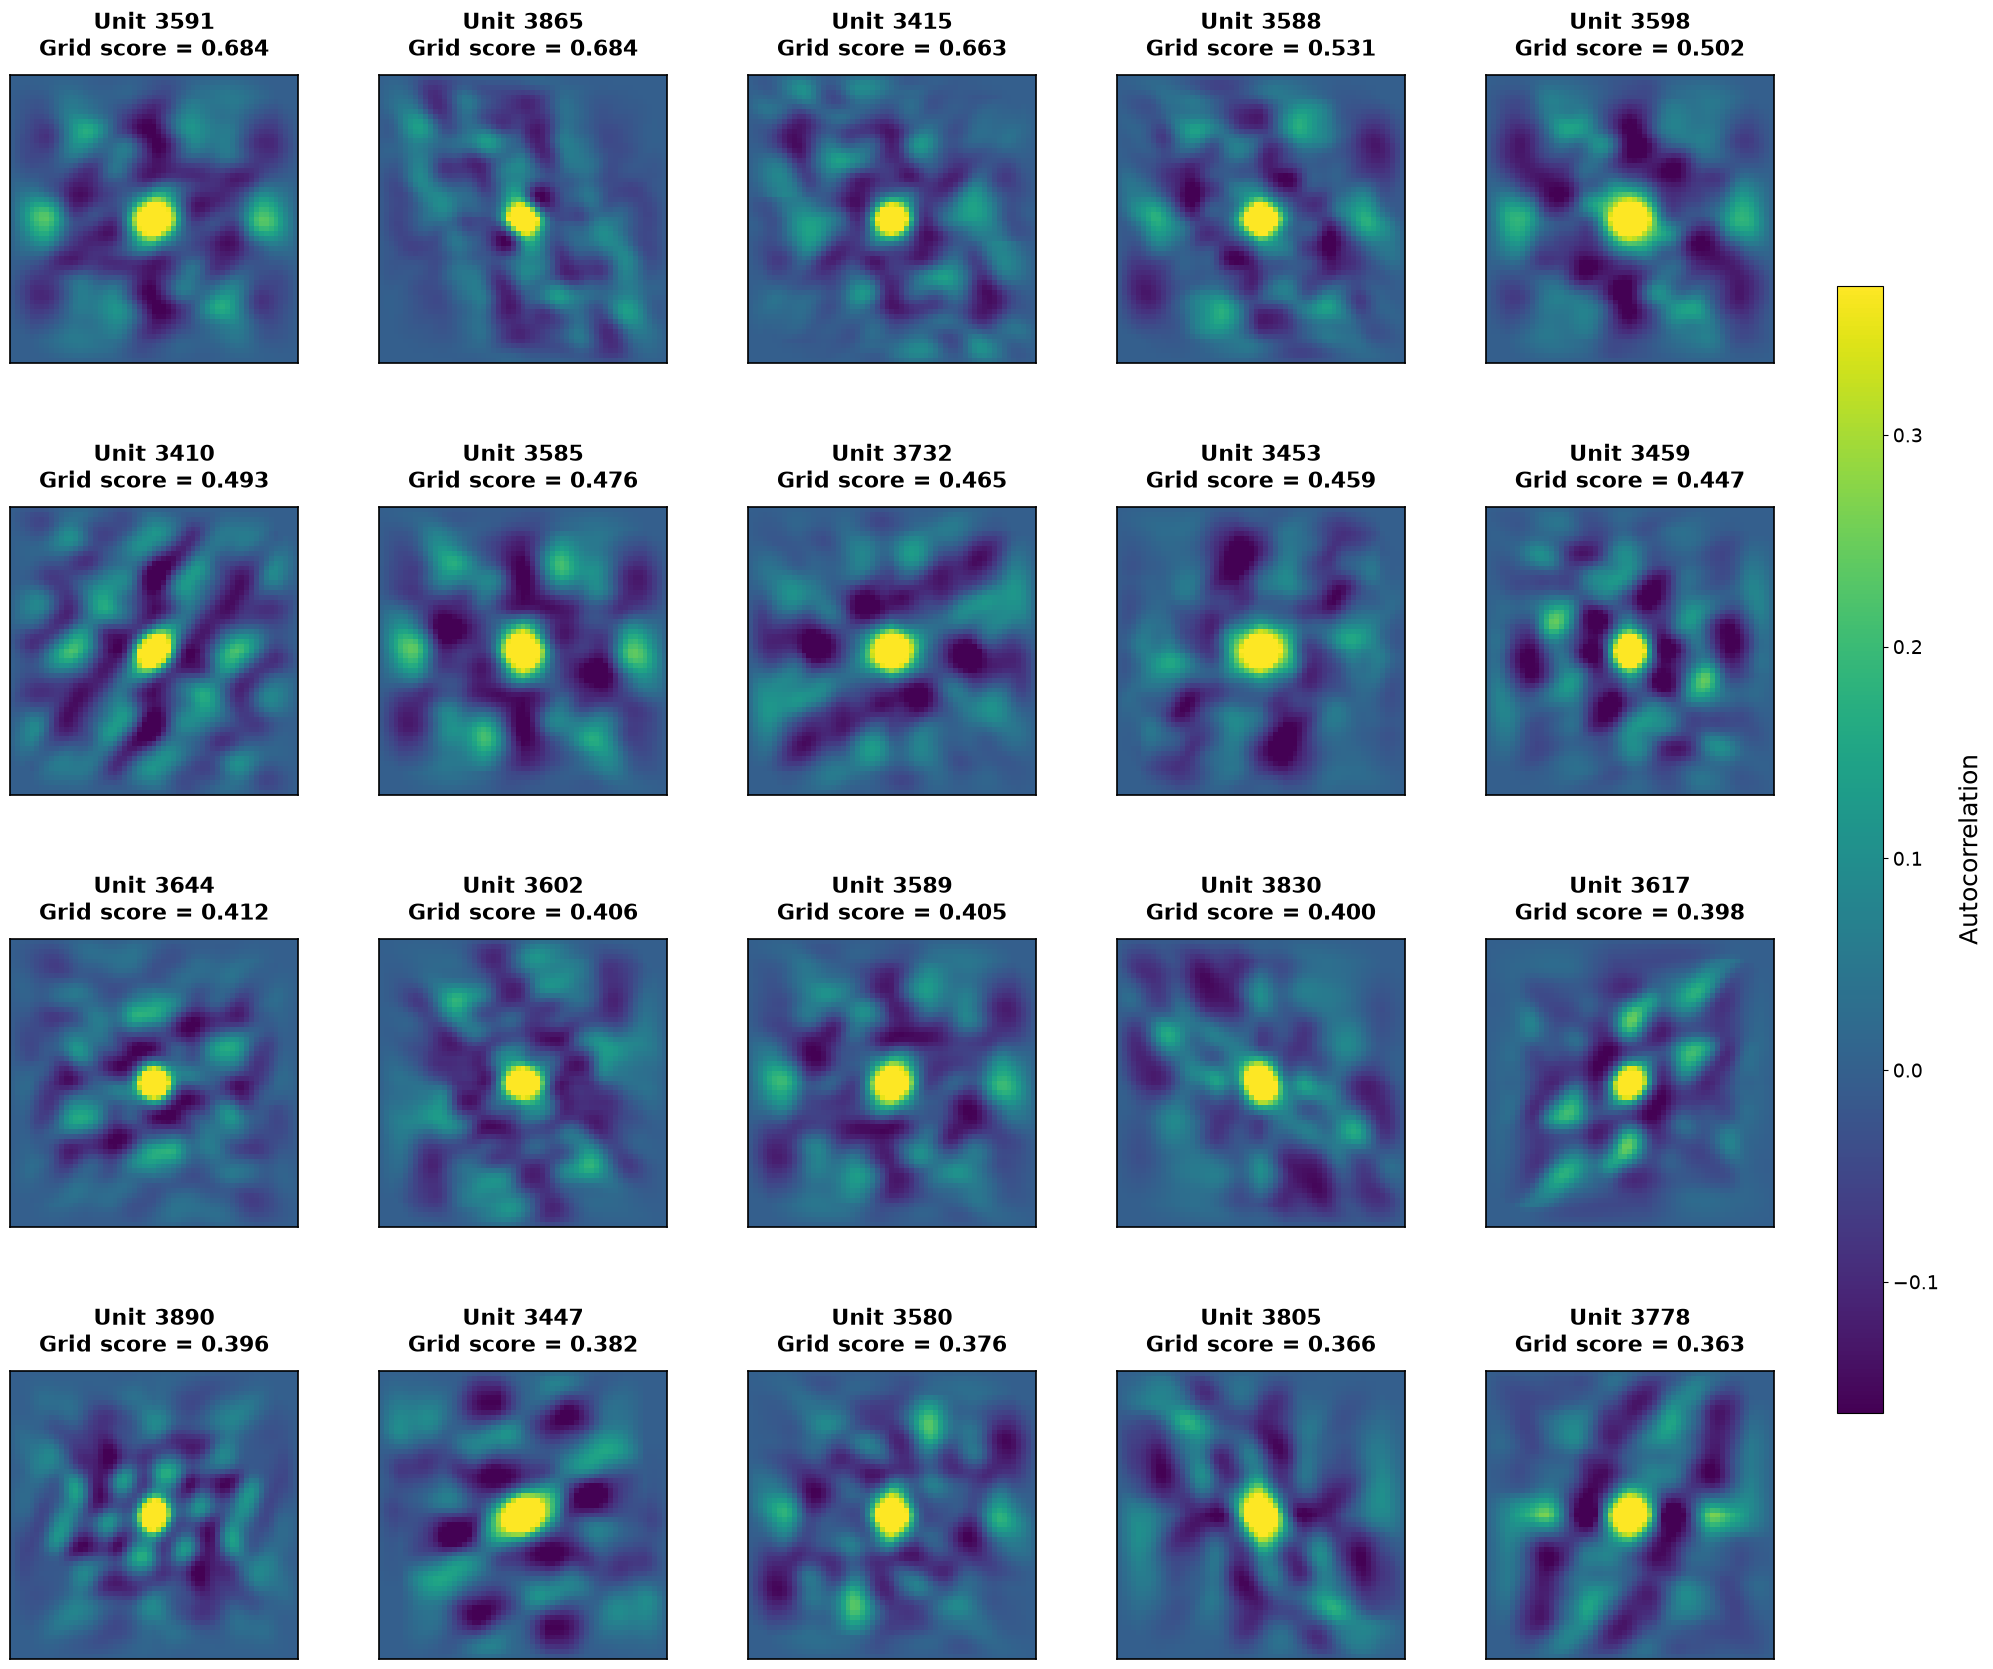

In [28]:
import matplotlib.pyplot as plt
import numpy as np

TOP_N = 20

top_cells = (
    grid_reg
    .query("brain_region == 'EC'")
    .dropna(subset=["grid_score"])
    .sort_values("grid_score", ascending=False)
    .head(TOP_N)
)

ncols = 5
nrows = int(np.ceil(TOP_N / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, 4.4 * nrows)
)

axes = np.ravel(axes)

# Use one common scale across all autocorrelograms
all_acorrs = []

for _, row in top_cells.iterrows():
    unit = int(row["unit_index"])
    rate_map = get_rate_map_for_unit(unit, map_df)
    all_acorrs.append(autocorr2d(rate_map))

all_values = np.concatenate([
    a[np.isfinite(a)].ravel()
    for a in all_acorrs
])

vmin = np.nanpercentile(all_values, 1)
vmax = np.nanpercentile(all_values, 99)

for ax, (_, row), acorr in zip(
    axes,
    top_cells.iterrows(),
    all_acorrs
):
    unit = int(row["unit_index"])
    score = float(row["grid_score"])

    im = ax.imshow(
        acorr,
        origin="lower",
        cmap="viridis",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f"Unit {unit}\nGrid score = {score:.3f}",
        fontsize=16,
        fontweight="bold",
        pad=14
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Hide unused panels
for ax in axes[len(top_cells):]:
    ax.axis("off")

# Leave room on right for colorbar
fig.subplots_adjust(
    left=0.04,
    right=0.88,
    bottom=0.04,
    top=0.94,
    wspace=0.28,
    hspace=0.50
)

# Dedicated colorbar axis on the right
cbar_ax = fig.add_axes([
    0.91,   # left
    0.18,   # bottom
    0.022,  # width
    0.64    # height
])

cbar = fig.colorbar(
    im,
    cax=cbar_ax
)

cbar.set_label(
    "Autocorrelation",
    fontsize=18,
    labelpad=14
)

cbar.ax.tick_params(
    labelsize=14
)

plt.show()

   unit_index  grid_score
0        3591    0.684139
1        3865    0.684110

Unit 3591: 874 valid bins
Stored gridness = 0.684139
Recomputed gridness = 0.684139
Valid permutations = 1000
Null mean = -0.033756
Null 95th percentile = 0.054837
Permutation p = 0.000999
Observed percentile = 100.00

Unit 3865: 874 valid bins
Stored gridness = 0.684110
Recomputed gridness = 0.684110
Valid permutations = 1000
Null mean = -0.033393
Null 95th percentile = 0.064200
Permutation p = 0.000999
Observed percentile = 100.00


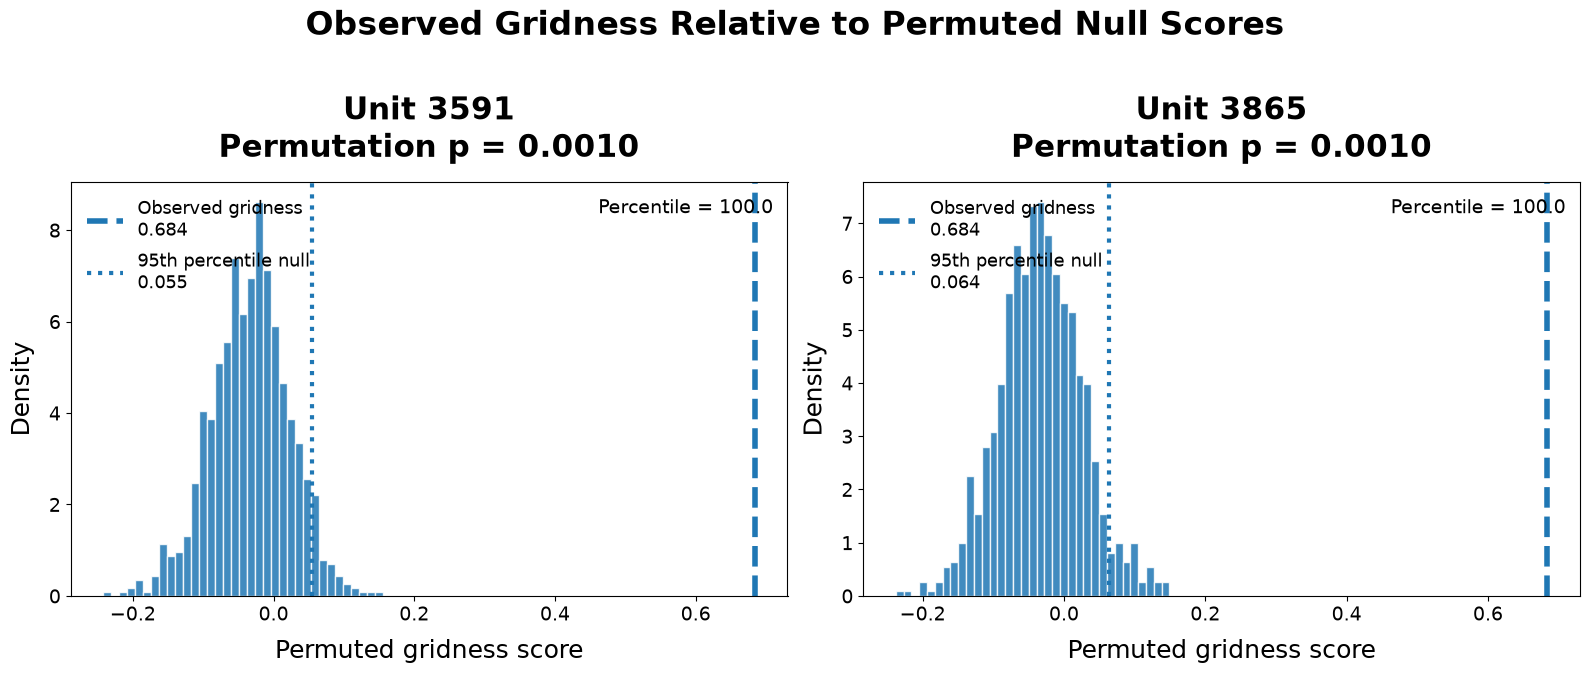

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import rotate
from scipy.stats import pearsonr


# ============================================================
# SETTINGS
# ============================================================
N_PERMUTATIONS = 1000
RANDOM_SEED = 123

rng = np.random.default_rng(RANDOM_SEED)


# ============================================================
# GRIDNESS FUNCTIONS
# Uses safe names so nothing is overwritten by a float
# ============================================================
def compute_autocorr2d(rate_map):
    """
    Normalized 2D spatial autocorrelation.
    """
    M = np.asarray(rate_map, dtype=float)
    valid = np.isfinite(M)

    if valid.sum() < 5:
        return None

    mean_value = np.nanmean(M)

    M_centered = np.where(
        valid,
        M - mean_value,
        0.0
    )

    F = np.fft.fft2(
        M_centered,
        s=(
            M.shape[0] * 2 - 1,
            M.shape[1] * 2 - 1
        )
    )

    autocorr = np.fft.ifft2(
        F * np.conj(F)
    ).real

    autocorr = np.fft.fftshift(
        autocorr
    )

    normalization = np.nanmax(
        np.abs(autocorr)
    )

    if (
        not np.isfinite(normalization)
        or normalization <= 1e-12
    ):
        return None

    return autocorr / normalization


def make_annulus_mask(
    shape,
    inner_frac=0.2,
    outer_frac=0.75
):
    """
    Annular mask excluding the central autocorrelation peak.
    """
    height, width = shape

    yy, xx = np.indices(shape)

    center_y = (height - 1) / 2
    center_x = (width - 1) / 2

    radius = np.sqrt(
        (yy - center_y) ** 2
        +
        (xx - center_x) ** 2
    )

    maximum_radius = min(
        height,
        width
    ) / 2

    return (
        (radius >= inner_frac * maximum_radius)
        &
        (radius <= outer_frac * maximum_radius)
    )


def correlate_on_mask(
    array_a,
    array_b,
    mask
):
    """
    Pearson correlation between two arrays within a mask.
    """
    values_a = array_a[mask]
    values_b = array_b[mask]

    valid = (
        np.isfinite(values_a)
        &
        np.isfinite(values_b)
    )

    if valid.sum() < 10:
        return np.nan

    if (
        np.std(values_a[valid]) <= 1e-12
        or
        np.std(values_b[valid]) <= 1e-12
    ):
        return np.nan

    return float(
        pearsonr(
            values_a[valid],
            values_b[valid]
        )[0]
    )


def compute_gridness_score(rate_map):
    """
    Classic gridness score:

    min(r60, r120) - max(r30, r90, r150)
    """
    autocorr = compute_autocorr2d(
        rate_map
    )

    if autocorr is None:
        return np.nan

    mask = make_annulus_mask(
        autocorr.shape
    )

    rotation_correlations = {}

    for angle in [
        30,
        60,
        90,
        120,
        150
    ]:
        rotated_autocorr = rotate(
            autocorr,
            angle=angle,
            reshape=False,
            order=1,
            mode="constant",
            cval=np.nan
        )

        rotation_correlations[angle] = (
            correlate_on_mask(
                autocorr,
                rotated_autocorr,
                mask
            )
        )

    required_values = np.asarray(
        list(
            rotation_correlations.values()
        ),
        dtype=float
    )

    if not np.all(
        np.isfinite(required_values)
    ):
        return np.nan

    positive_rotation_similarity = min(
        rotation_correlations[60],
        rotation_correlations[120]
    )

    negative_rotation_similarity = max(
        rotation_correlations[30],
        rotation_correlations[90],
        rotation_correlations[150]
    )

    return float(
        positive_rotation_similarity
        -
        negative_rotation_similarity
    )


# ============================================================
# RATE-MAP FUNCTION
# Uses your actual map_df columns
# ============================================================
def get_unit_rate_map(
    unit_index,
    map_dataframe
):
    unit_data = (
        map_dataframe.loc[
            map_dataframe["unit_index"]
            ==
            unit_index
        ]
        .copy()
    )

    if unit_data.empty:
        return None

    rate_map = (
        unit_data
        .pivot(
            index="pca_bin_y",
            columns="pca_bin_x",
            values="rate"
        )
        .sort_index(
            axis=0,
            ascending=True
        )
        .sort_index(
            axis=1,
            ascending=True
        )
        .to_numpy(
            dtype=float
        )
    )

    return rate_map


# ============================================================
# SELECT TOP TWO CELLS
# ============================================================
top_two_cells = (
    grid_reg
    .query("brain_region == 'EC'")
    .dropna(subset=["grid_score"])
    .sort_values(
        "grid_score",
        ascending=False
    )
    .head(2)
    .reset_index(drop=True)
)

print(
    top_two_cells[
        [
            "unit_index",
            "grid_score"
        ]
    ]
)


# ============================================================
# PERMUTATION TEST
# ============================================================
permutation_results = []

for _, cell_row in top_two_cells.iterrows():

    unit_index = int(
        cell_row["unit_index"]
    )

    stored_gridness = float(
        cell_row["grid_score"]
    )

    observed_rate_map = get_unit_rate_map(
        unit_index,
        map_df
    )

    if observed_rate_map is None:
        print(
            f"Unit {unit_index}: "
            "rate map not found."
        )
        continue

    valid_bin_mask = np.isfinite(
        observed_rate_map
    )

    observed_bin_values = (
        observed_rate_map[
            valid_bin_mask
        ]
    )

    if len(observed_bin_values) < 10:
        print(
            f"Unit {unit_index}: "
            "too few valid bins."
        )
        continue

    recomputed_gridness = (
        compute_gridness_score(
            observed_rate_map
        )
    )

    print(
        f"\nUnit {unit_index}: "
        f"{valid_bin_mask.sum()} valid bins"
    )

    print(
        f"Stored gridness = "
        f"{stored_gridness:.6f}"
    )

    print(
        f"Recomputed gridness = "
        f"{recomputed_gridness:.6f}"
    )

    permuted_gridness_scores = []

    for permutation_index in range(
        N_PERMUTATIONS
    ):
        permuted_rate_map = (
            observed_rate_map.copy()
        )

        permuted_rate_map[
            valid_bin_mask
        ] = rng.permutation(
            observed_bin_values
        )

        permuted_gridness = (
            compute_gridness_score(
                permuted_rate_map
            )
        )

        if np.isfinite(
            permuted_gridness
        ):
            permuted_gridness_scores.append(
                float(
                    permuted_gridness
                )
            )

    permuted_gridness_scores = (
        np.asarray(
            permuted_gridness_scores,
            dtype=float
        )
    )

    if len(
        permuted_gridness_scores
    ) == 0:
        print(
            f"Unit {unit_index}: "
            "all permutations were invalid."
        )
        continue

    permutation_p = (
        1
        +
        np.sum(
            permuted_gridness_scores
            >=
            recomputed_gridness
        )
    ) / (
        len(
            permuted_gridness_scores
        )
        +
        1
    )

    percentile = (
        100
        *
        np.mean(
            permuted_gridness_scores
            <
            recomputed_gridness
        )
    )

    null_mean = np.mean(
        permuted_gridness_scores
    )

    null_95 = np.percentile(
        permuted_gridness_scores,
        95
    )

    permutation_results.append({
        "unit_index": unit_index,
        "stored_gridness": stored_gridness,
        "observed_gridness": (
            recomputed_gridness
        ),
        "null_scores": (
            permuted_gridness_scores
        ),
        "null_mean": null_mean,
        "null_95": null_95,
        "p_value": permutation_p,
        "percentile": percentile
    })

    print(
        f"Valid permutations = "
        f"{len(permuted_gridness_scores)}"
    )

    print(
        f"Null mean = "
        f"{null_mean:.6f}"
    )

    print(
        f"Null 95th percentile = "
        f"{null_95:.6f}"
    )

    print(
        f"Permutation p = "
        f"{permutation_p:.6f}"
    )

    print(
        f"Observed percentile = "
        f"{percentile:.2f}"
    )


# ============================================================
# CHECK THAT BOTH CELLS WORKED
# ============================================================
if len(permutation_results) == 0:
    raise RuntimeError(
        "No valid permutation distributions "
        "were generated."
    )


# ============================================================
# PLOT
# ============================================================
n_cells = len(
    permutation_results
)

fig, axes = plt.subplots(
    1,
    n_cells,
    figsize=(
        8 * n_cells,
        6.5
    ),
    squeeze=False
)

axes = axes.ravel()

for ax, result in zip(
    axes,
    permutation_results
):
    null_scores = result[
        "null_scores"
    ]

    observed_gridness = result[
        "observed_gridness"
    ]

    null_95 = result[
        "null_95"
    ]

    unit_index = result[
        "unit_index"
    ]

    p_value = result[
        "p_value"
    ]

    percentile = result[
        "percentile"
    ]

    ax.hist(
        null_scores,
        bins=35,
        density=True,
        alpha=0.85,
        edgecolor="white",
        linewidth=1
    )

    ax.axvline(
        observed_gridness,
        linewidth=4,
        linestyle="--",
        label=(
            "Observed gridness\n"
            f"{observed_gridness:.3f}"
        )
    )

    ax.axvline(
        null_95,
        linewidth=3,
        linestyle=":",
        label=(
            "95th percentile null\n"
            f"{null_95:.3f}"
        )
    )

    ax.set_title(
        f"Unit {unit_index}\n"
        f"Permutation p = {p_value:.4f}",
        fontsize=22,
        fontweight="bold",
        pad=18
    )

    ax.set_xlabel(
        "Permuted gridness score",
        fontsize=18,
        labelpad=10
    )

    ax.set_ylabel(
        "Density",
        fontsize=18,
        labelpad=10
    )

    ax.tick_params(
        axis="both",
        labelsize=14
    )

    ax.legend(
        fontsize=13,
        frameon=False,
        loc="upper left"
    )

    ax.text(
        0.98,
        0.96,
        f"Percentile = {percentile:.1f}",
        transform=ax.transAxes,
        horizontalalignment="right",
        verticalalignment="top",
        fontsize=14
    )

fig.suptitle(
    "Observed Gridness Relative to Permuted Null Scores",
    fontsize=24,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

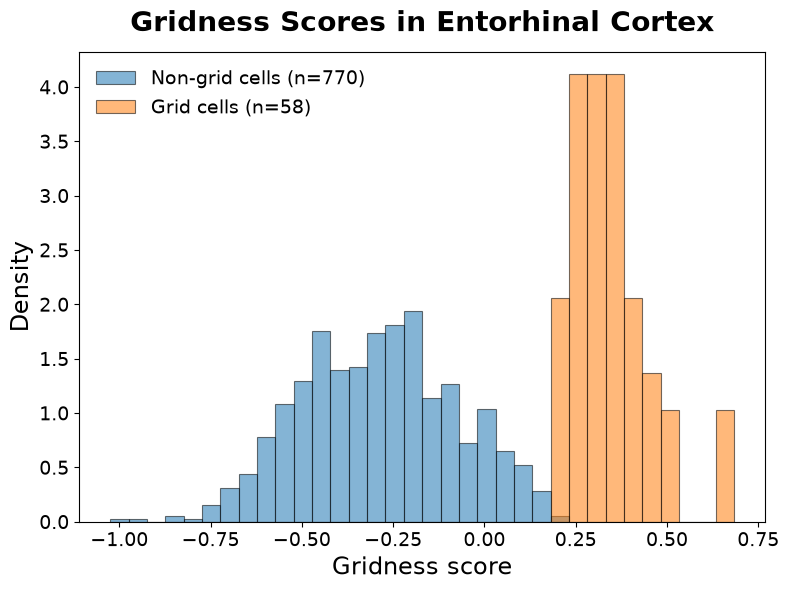

Total EC cells: 828
EC grid cells: 58
EC non-grid cells: 770
Grid-cell mean: 0.346
Non-grid-cell mean: -0.289


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Entorhinal cortex only
ec_df = (
    grid_reg.loc[
        grid_reg["brain_region"] == "EC"
    ]
    .dropna(subset=["grid_score", "grid_cell"])
    .copy()
)

# Handle grid_cell if loaded as text
if ec_df["grid_cell"].dtype != bool:
    ec_df["grid_cell"] = (
        ec_df["grid_cell"]
        .astype(str)
        .str.lower()
        .map({
            "true": True,
            "false": False
        })
    )

grid_scores = ec_df.loc[
    ec_df["grid_cell"] == True,
    "grid_score"
]

nongrid_scores = ec_df.loc[
    ec_df["grid_cell"] == False,
    "grid_score"
]

# Shared bins
bins = np.linspace(ec_df["grid_score"].min(),ec_df["grid_score"].max(),35)

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    nongrid_scores,
    bins=bins,
    density=True,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.8,
    label=f"Non-grid cells (n={len(nongrid_scores)})"
)

ax.hist(
    grid_scores,
    bins=bins,
    density=True,
    alpha=0.55,
    edgecolor="black",
    linewidth=0.8,
    label=f"Grid cells (n={len(grid_scores)})"
)

ax.set_xlabel("Gridness score",fontsize=17)

ax.set_ylabel(
    "Density",
    fontsize=17
)

ax.set_title(
    "Gridness Scores in Entorhinal Cortex",
    fontsize=20,
    fontweight="bold",
    pad=15
)

ax.tick_params(axis="both",labelsize=14)
ax.legend(fontsize=14,frameon=False)
plt.tight_layout()
plt.show()
print(f"Total EC cells: {len(ec_df)}")
print(f"EC grid cells: {len(grid_scores)}")
print(f"EC non-grid cells: {len(nongrid_scores)}")
print(f"Grid-cell mean: {grid_scores.mean():.3f}")
print(f"Non-grid-cell mean: {nongrid_scores.mean():.3f}")